In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import kagglehub

C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("florianhinrichsen/nyc-taxi-data-2023-24")

PUs_df = pd.read_parquet(f"{path}\hourlyPUs2023-24WEATHER.parquet")
DOs_df = pd.read_parquet(f"{path}\hourlyDOs2023-24WEATHER.parquet")

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 50

### Trip count

Average trip count by hour

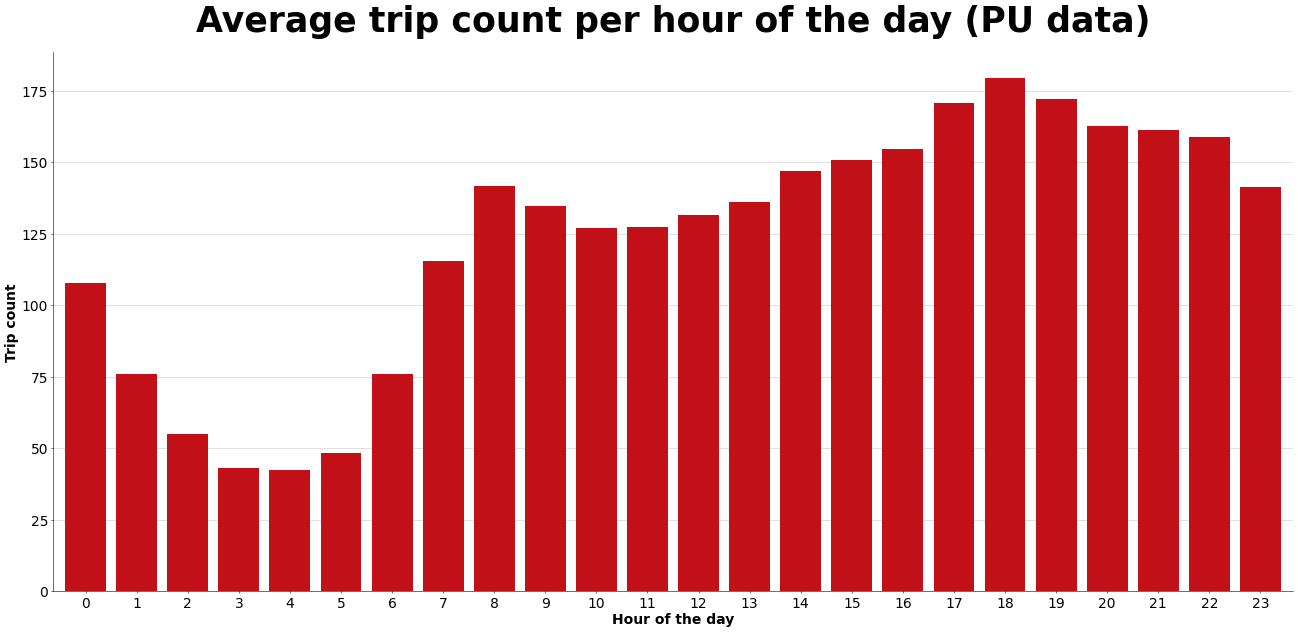

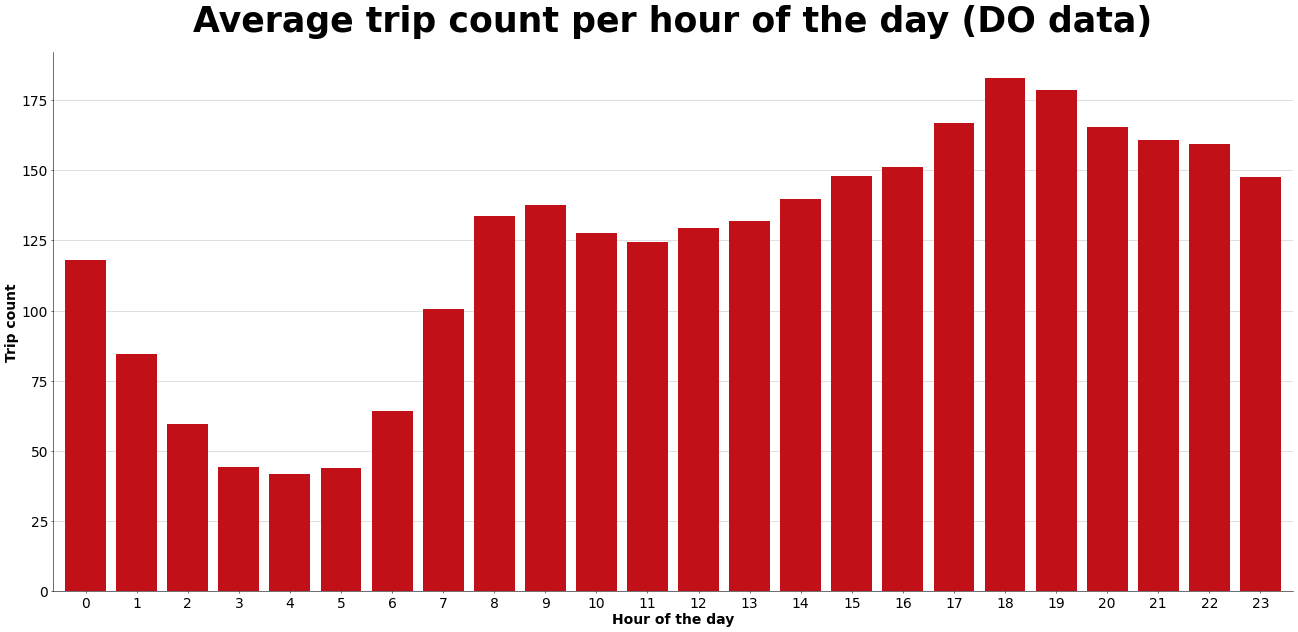

In [3]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Hourly Average Trip Counts
# ---------------------------------------------------------
# Group the datasets by hour of the day and calculate the mean trip count.
hourly_PUs = PUs_df.groupby("hour")["trip_count"].mean().reset_index()
hourly_DOs = DOs_df.groupby("hour")["trip_count"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Hourly Averages
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to average trip counts.
plt.bar(
    hourly_PUs["hour"],
    hourly_PUs["trip_count"],
    color="#C21019"
)

# Set title, axes labels, and margins.
plt.title("Average trip count per hour of the day (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip count", fontweight="bold")
plt.margins(x=0.01)
plt.xticks(range(0, 24))

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Export the figure (using forward slashes for the directory path).
#plt.savefig("Plots/Distributions/TripCount/PUsHourlyTripCount.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Hourly Averages
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to average trip counts.
plt.bar(
    hourly_DOs["hour"],
    hourly_DOs["trip_count"],
    color="#C21019"
)

# Set title, axes labels, and margins.
plt.title("Average trip count per hour of the day (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip count", fontweight="bold")
plt.margins(x=0.01)
plt.xticks(range(0, 24))

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Export the figure.
#plt.savefig("Plots/Distributions/TripCount/DOsHourlyTripCount.png", dpi=300)
plt.show()

Average trip count by day of week

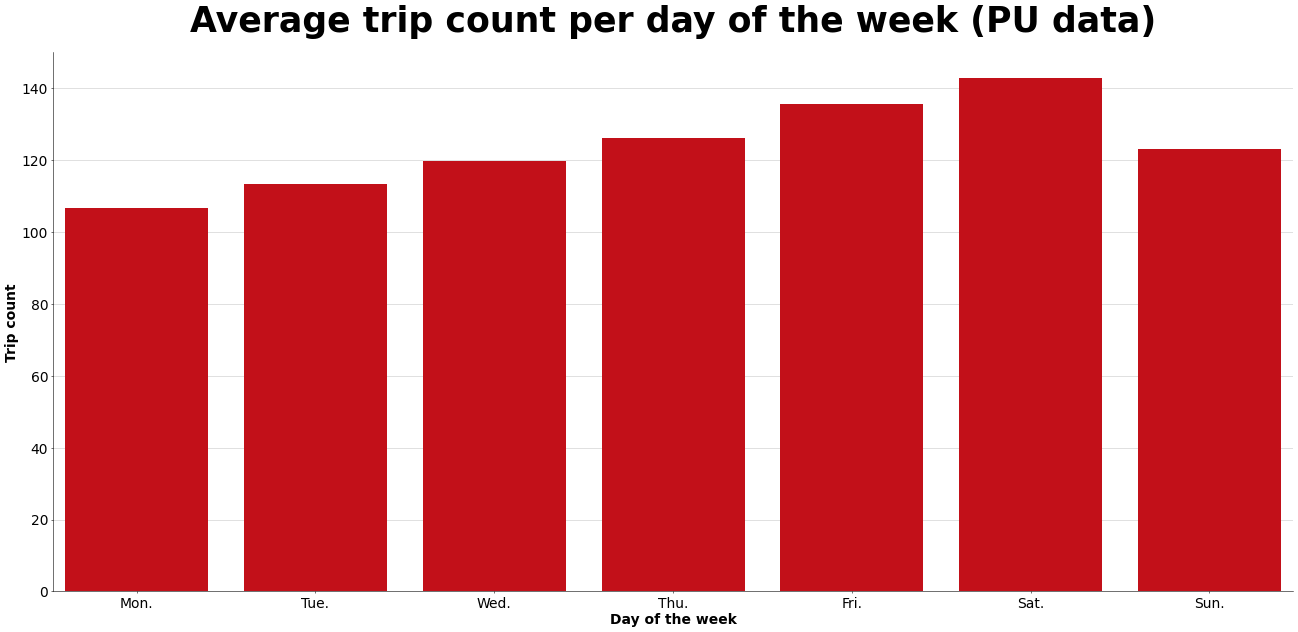

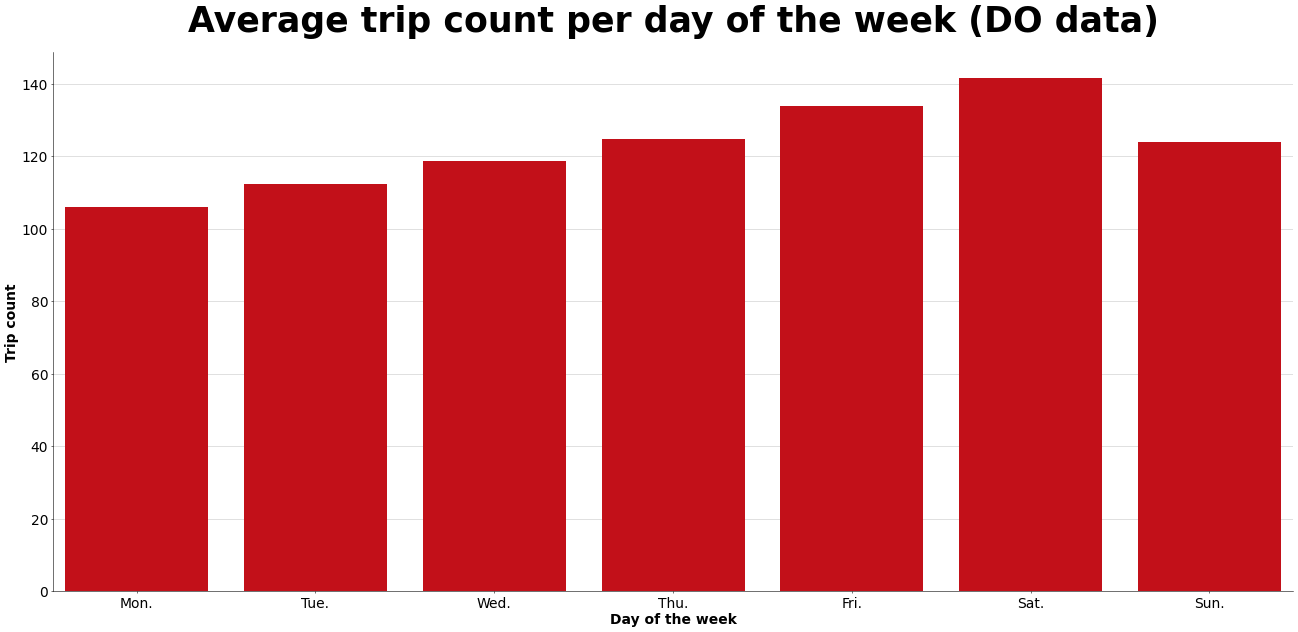

In [4]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Daily Average Trip Counts
# ---------------------------------------------------------
# Group the datasets by day of the week and calculate the mean trip count.
daily_PUs = PUs_df.groupby("DayOfWeek")["trip_count"].mean().reset_index()
daily_DOs = DOs_df.groupby("DayOfWeek")["trip_count"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Daily Averages
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to average trip counts.
plt.bar(
    daily_PUs["DayOfWeek"],
    daily_PUs["trip_count"],
    color="#C21019"
)

# Set title, axes labels, and margins.
plt.title("Average trip count per day of the week (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip count", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# Export the figure (using forward slashes for the directory path).
#plt.savefig("Plots/Distributions/TripCount/PUsDailyTripCount.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Daily Averages
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to average trip counts.
plt.bar(
    daily_DOs["DayOfWeek"],
    daily_DOs["trip_count"],
    color="#C21019"
)

# Set title, axes labels, and margins.
plt.title("Average trip count per day of the week (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip count", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# Export the figure.
#plt.savefig("Plots/Distributions/TripCount/DOsDailyTripCount.png", dpi=300)
plt.show()

Trip count by day of week with a seperate bar for holidays

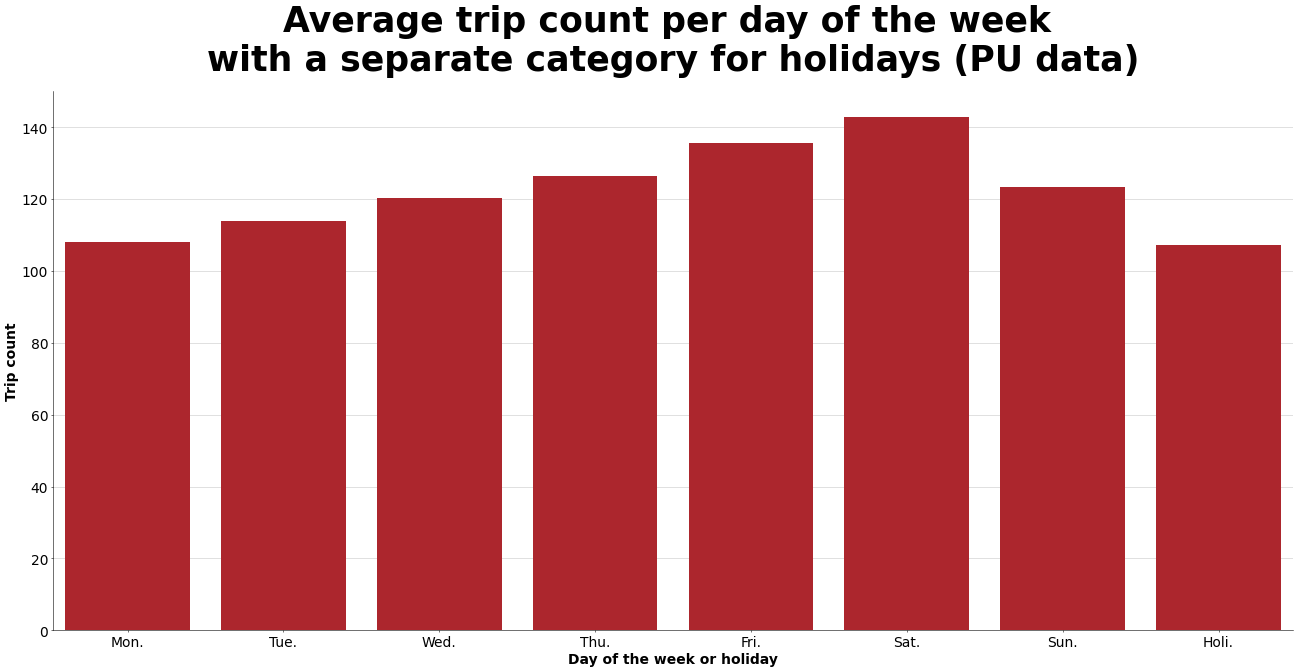

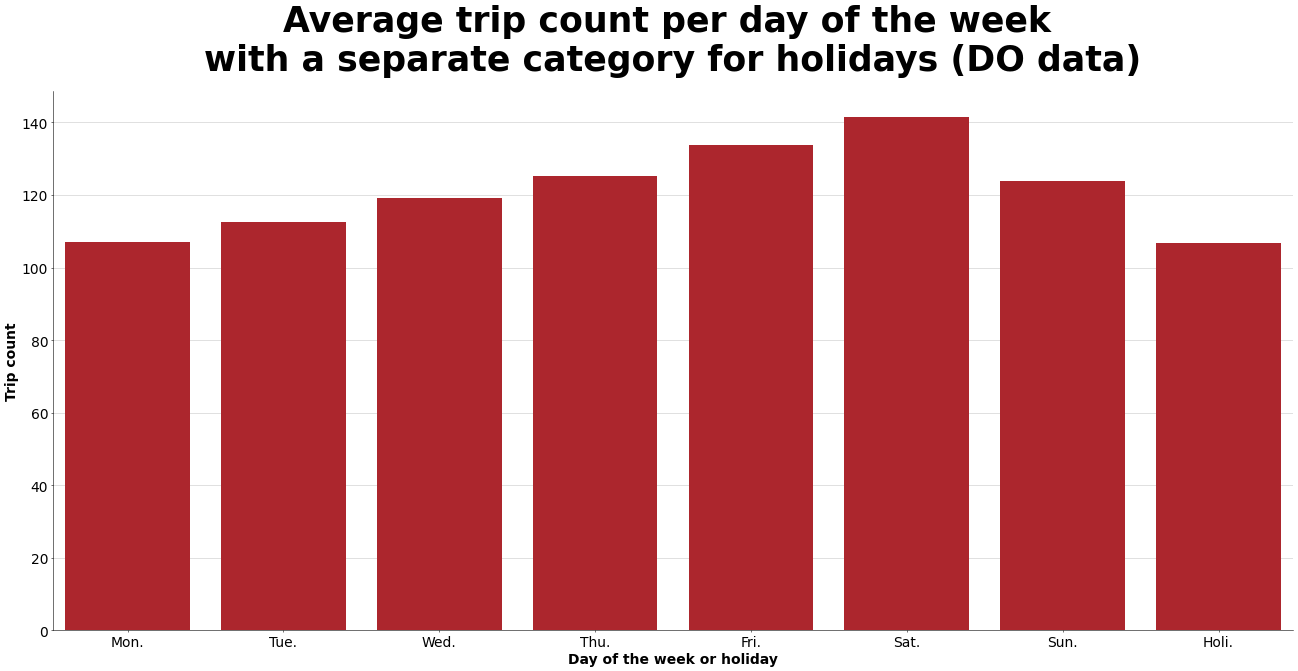

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Data Processing: Pick-Up (PU) Holiday Grouping
# ---------------------------------------------------------
# Map numerical day of the week indicators to explicit string names.
# (AI generated)
day_mapping = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday",
    3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"
}

PUs_df["day"] = PUs_df["DayOfWeek"].map(day_mapping) # AI generated

# Isolate recognized holidays into a distinct categorical group.
# (AI generated)
PUs_df["day_group"] = np.where(PUs_df["is_holiday"] == True, "Holiday", PUs_df["day"])

# Aggregate the average trip count per group.
# (AI generated)
daily_df = PUs_df.groupby("day_group")["trip_count"].mean().reset_index()

# Define a strict categorical order to ensure the holiday column renders at the end.
# (AI generated)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "Holiday"]
daily_df["day_group"] = pd.Categorical(daily_df["day_group"], categories=day_order, ordered=True)

# Sort values by the predefined categorical order.
# (AI generated)
grouped_df = daily_df.sort_values("day_group")

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Holiday Distribution
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar plot mapping the categorized days against trip volumes.
sns.barplot(
    data=daily_df,
    x="day_group",
    y="trip_count",
    color="#C21019" 
)

# Configure plot aesthetics, titles, and axis boundaries.
plt.title("Average trip count per day of the week \nwith a separate category for holidays (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week or holiday", fontweight="bold")
plt.ylabel("Trip count", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated labels including the holiday bin.
plt.xticks(range(0, 8), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun.", "Holi."])

# Export the high-resolution figure (using forward slashes for the directory path).
#plt.savefig("Plots/Distributions/TripCount/PUsDailyHolidayTripCount.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 3. Data Processing: Drop-Off (DO) Holiday Grouping
# ---------------------------------------------------------
# Apply the exact same mapping and grouping transformations to the Drop-Off dataset.
# (AI generated)
DOs_df["day"] = DOs_df["DayOfWeek"].map(day_mapping)
DOs_df["day_group"] = np.where(DOs_df["is_holiday"] == True, "Holiday", DOs_df["day"])

daily_df = DOs_df.groupby("day_group")["trip_count"].mean().reset_index()
daily_df["day_group"] = pd.Categorical(daily_df["day_group"], categories=day_order, ordered=True)
grouped_df = daily_df.sort_values("day_group")

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Holiday Distribution
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar plot mapping the categorized days against trip volumes.
sns.barplot(
    data=daily_df,
    x="day_group",
    y="trip_count",
    color="#C21019" 
)

# Configure plot aesthetics, titles, and axis boundaries.
plt.title("Average trip count per day of the week \nwith a separate category for holidays (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week or holiday", fontweight="bold")
plt.ylabel("Trip count", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated labels including the holiday bin.
plt.xticks(range(0, 8), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun.", "Holi."])

# Export the high-resolution figure.
#plt.savefig("Plots/Distributions/TripCount/DOsDailyHolidayTripCount.png", dpi=300)
plt.show()

Hourly distribution of trip count by day of week

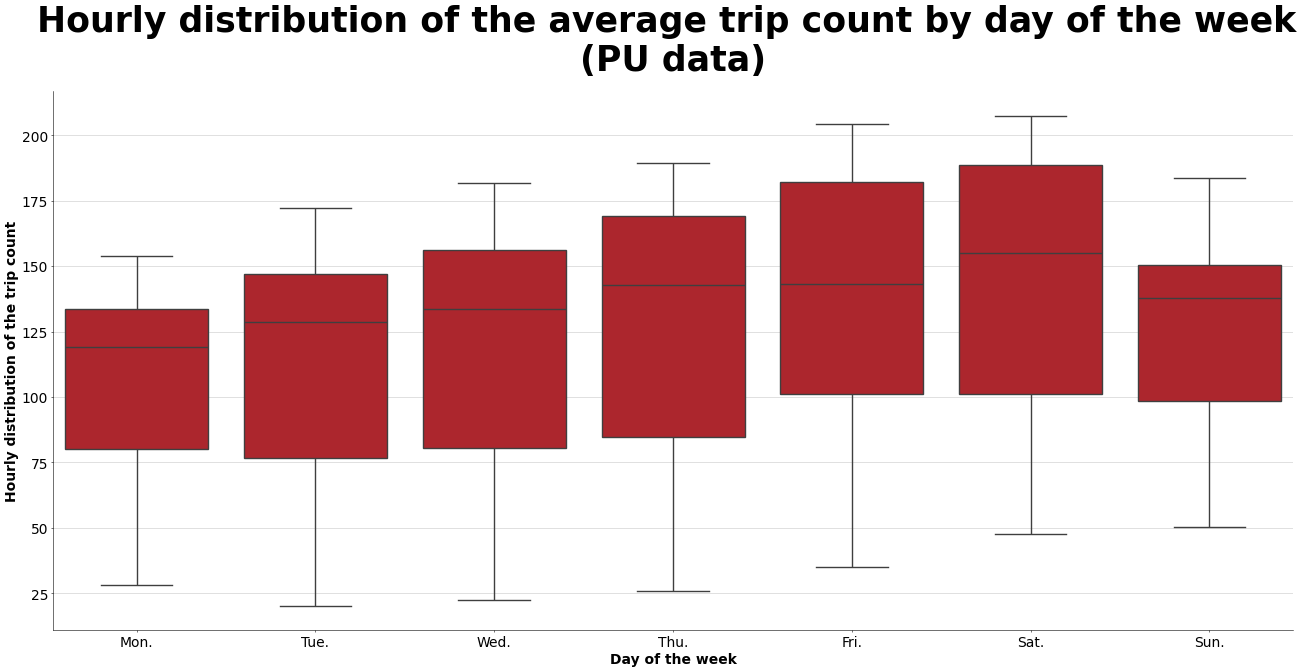

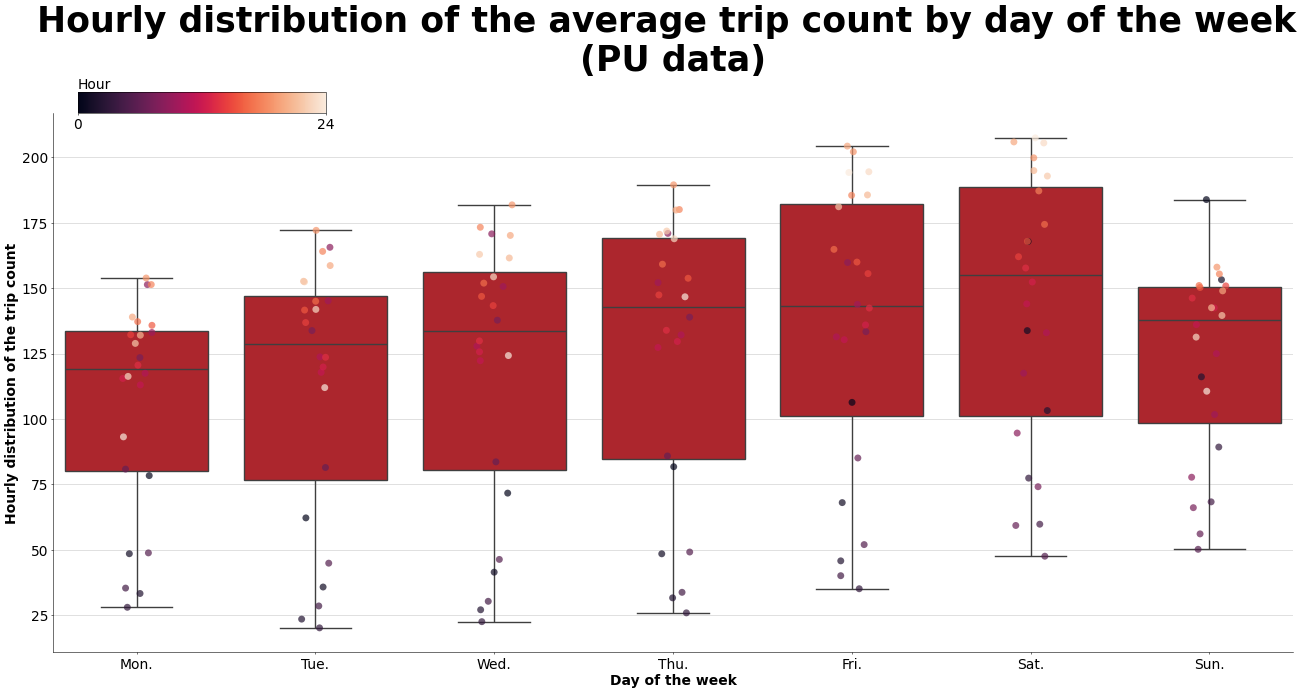

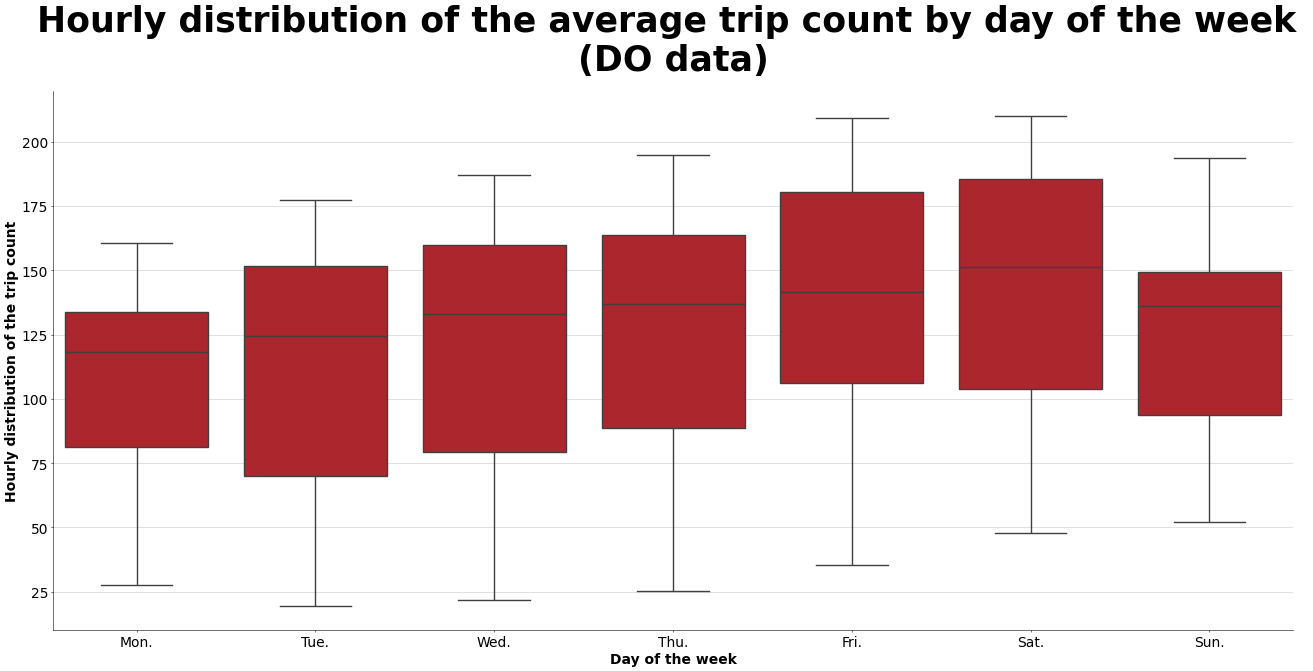

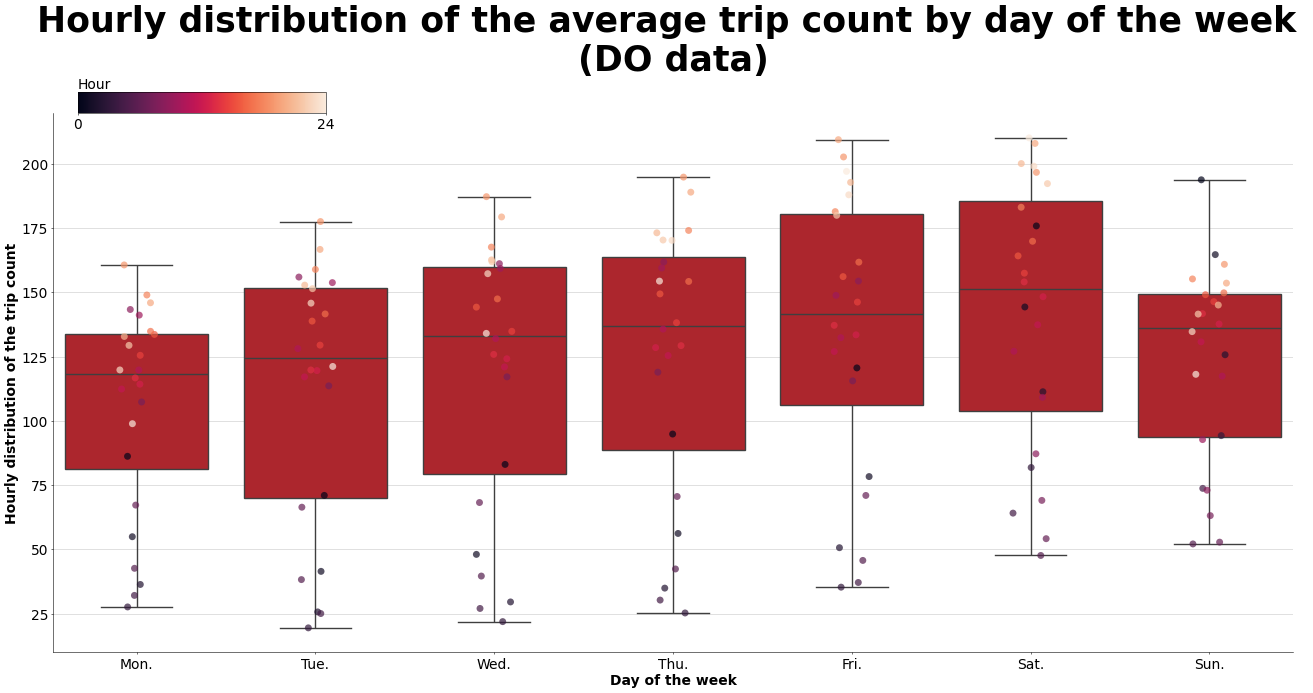

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# ---------------------------------------------------------
# 1. Data Aggregation: Hourly Distribution by Day
# ---------------------------------------------------------
# Group by DayOfWeek and hour to calculate mean trip counts.
hourly_distPUs = PUs_df.groupby(["DayOfWeek", "hour"])["trip_count"].mean().reset_index()
hourly_distDOs = DOs_df.groupby(["DayOfWeek", "hour"])["trip_count"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Standard Boxplot
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

sns.boxplot(
    data=hourly_distPUs,
    x="DayOfWeek",
    y="trip_count",
    color="#C21019",       
    linewidth=2,         
    showfliers=False  
)

plt.title("Hourly distribution of the average trip count by day of the week \n(PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Hourly distribution of the trip count", fontweight="bold")
plt.margins(x=0.01)
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

#plt.savefig("Plots/Distributions/TripCount/PUsDailyBoxplot.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Visualization: Pick-Up (PU) Boxplot + Stripplot
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

sns.boxplot(
    data=hourly_distPUs,
    x="DayOfWeek",
    y="trip_count",
    color="#C21019",       
    linewidth=2,         
    showfliers=False  
)

sns.stripplot(
    data=hourly_distPUs,
    x="DayOfWeek",
    y="trip_count",
    alpha=0.7,
    hue="hour",
    palette="rocket",
    size=10,
    legend=False
)

plt.title("Hourly distribution of the average trip count by day of the week \n(PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Hourly distribution of the trip count", fontweight="bold")
plt.margins(x=0.01)
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# Set up custom inset colorbar for the hour mapping.
# (AI generated)
norm = mcolors.Normalize(vmin=0, vmax=24)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="rocket")
cax = plt.gca().inset_axes([0.02, 1, 0.2, 0.04])

cbar = plt.colorbar(
    scalar_mappable, cax=cax, orientation="horizontal", ticks=[0, 24]
)

cbar.outline.set_visible(True)
cbar.ax.xaxis.set_tick_params(labelsize=20, pad=2)
cax.set_title("Hour", fontsize=20, loc="left", pad=5)   

#plt.savefig("Plots/Distributions/TripCount/PUsDailyHourlyBoxplot.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Standard Boxplot
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

sns.boxplot(
    data=hourly_distDOs,
    x="DayOfWeek",
    y="trip_count",
    color="#C21019",       
    linewidth=2,         
    showfliers=False  
)

plt.title("Hourly distribution of the average trip count by day of the week \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Hourly distribution of the trip count", fontweight="bold")
plt.margins(x=0.01)
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

#plt.savefig("Plots/Distributions/TripCount/DOsDailyBoxplot.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 5. Visualization: Drop-Off (DO) Boxplot + Stripplot
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

sns.boxplot(
    data=hourly_distDOs,
    x="DayOfWeek",
    y="trip_count",
    color="#C21019",       
    linewidth=2,         
    showfliers=False  
)

sns.stripplot(
    data=hourly_distDOs,
    x="DayOfWeek",
    y="trip_count",
    alpha=0.7,
    hue="hour",
    palette="rocket",
    size=10,
    legend=False 
)

plt.title("Hourly distribution of the average trip count by day of the week \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Hourly distribution of the trip count", fontweight="bold")
plt.margins(x=0.01)
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# Set up custom inset colorbar for the hour mapping.
# (AI generated)
norm = mcolors.Normalize(vmin=0, vmax=24)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="rocket")
cax = plt.gca().inset_axes([0.02, 1, 0.2, 0.04])

cbar = plt.colorbar(
    scalar_mappable, cax=cax, orientation="horizontal", ticks=[0, 24]
)

cbar.outline.set_visible(True)
cbar.ax.xaxis.set_tick_params(labelsize=20, pad=2)
cax.set_title("Hour", fontsize=20, loc="left", pad=5) 

#plt.savefig("Plots/Distributions/TripCount/DOsDailyHourlyBoxplot.png", dpi=300)
plt.show()

Heatmap of the trip count by hour and day of week

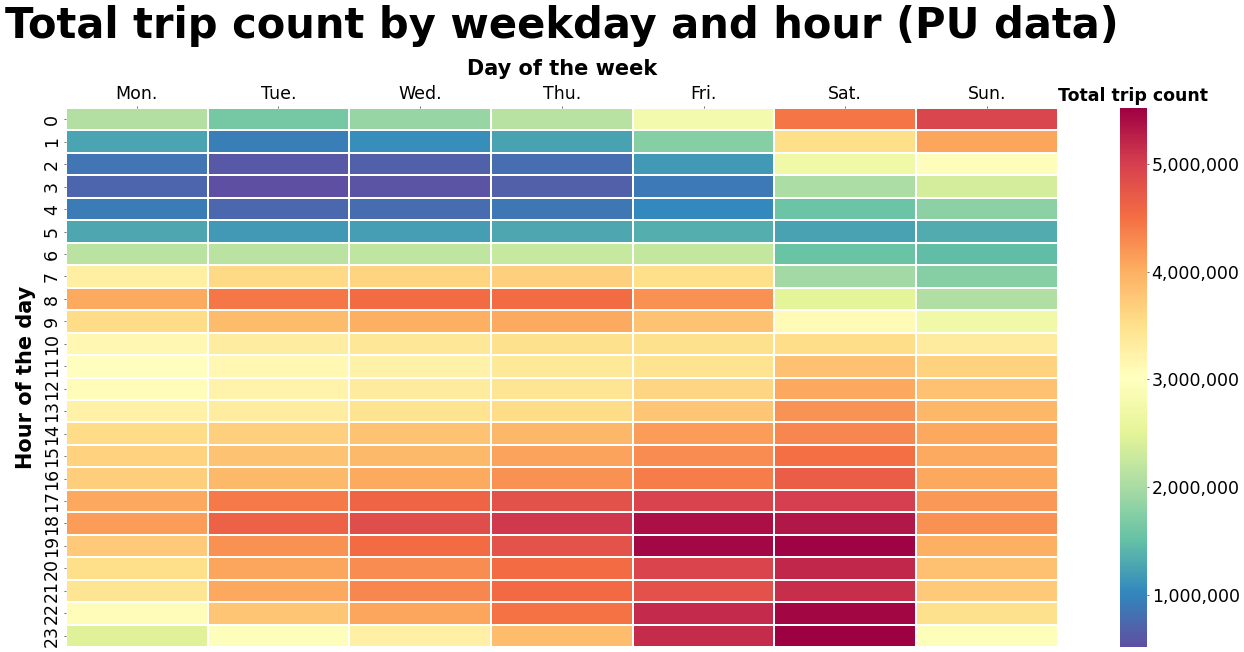

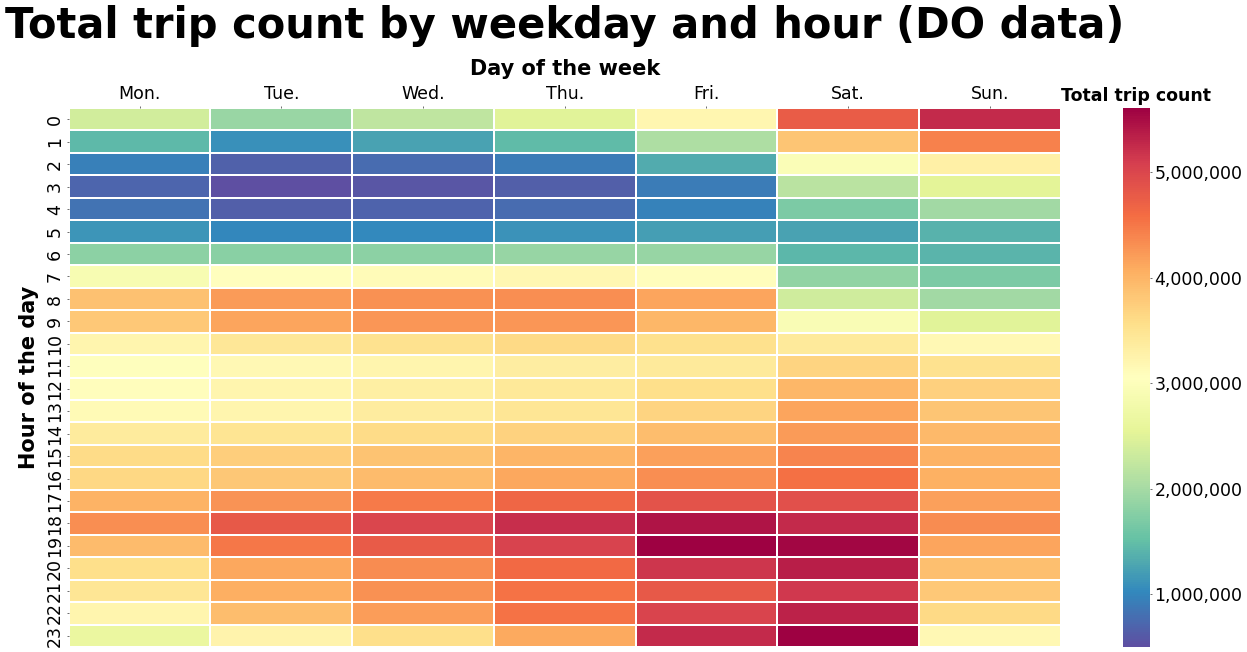

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Data Aggregation: Pick-Up (PU) Heatmap Matrix
# ---------------------------------------------------------
# Create a pivot table summing the trip counts by hour and DayOfWeek.
heatmap_PUs = pd.pivot_table(
    PUs_df,
    values="trip_count",
    index="hour",
    columns="DayOfWeek",
    aggfunc="sum"
)

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))
ax = sns.heatmap(
    data=heatmap_PUs,
    cmap="Spectral_r",
    linewidth=0.5,
    annot=False
)

# Set title, axes labels, tick formatting, and label positioning.
plt.title("Total trip count by weekday and hour (PU data)",
          fontsize=60, fontweight="bold", pad=30)
ax.set_xlabel("Day of the week", fontweight="bold", labelpad=15, fontsize=30)
ax.set_xticklabels(["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."], fontsize=25)
ax.set_ylabel("Hour of the day", fontweight="bold", labelpad=10, fontsize=30)
ax.tick_params(axis="y", labelsize=25)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Configure the colorbar to display integer values with comma separators.
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ","))) # AI generated
cbar.ax.set_title("Total trip count", pad=10, fontsize=25, fontweight="bold")
cbar.ax.tick_params(labelsize=25)

# Export the figure as a PDF with a tight bounding box.
#plt.savefig("Plots/Distributions/TripCount/PUsDailyHourlyHeatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------
# 3. Data Aggregation: Drop-Off (DO) Heatmap Matrix
# ---------------------------------------------------------
# Create a pivot table summing the trip counts by hour and DayOfWeek.
heatmap_DOs = pd.pivot_table(
    DOs_df,
    values="trip_count",
    index="hour",
    columns="DayOfWeek",
    aggfunc="sum"
)

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))
ax = sns.heatmap(
    data=heatmap_DOs,
    cmap="Spectral_r",
    linewidth=0.5,
    annot=False
)

# Set title, axes labels, tick formatting, and label positioning.
plt.title("Total trip count by weekday and hour (DO data)",
          fontsize=60, fontweight="bold", pad=30)
ax.set_xlabel("Day of the week", fontweight="bold", labelpad=15, fontsize=30)
ax.set_xticklabels(["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."], fontsize=25)
ax.set_ylabel("Hour of the day", fontweight="bold", labelpad=10, fontsize=30)
ax.tick_params(axis="y", labelsize=25)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Configure the colorbar to display integer values with comma separators.
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ","))) # AI generated
cbar.ax.set_title("Total trip count", pad=10, fontsize=25, fontweight="bold")
cbar.ax.tick_params(labelsize=25)

# Export the figure as a PDF with a tight bounding box.
#plt.savefig("Plots/Distributions/TripCount/DOsDailyHourlyHeatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

Boxplot of total trip count distribution by taxi zone

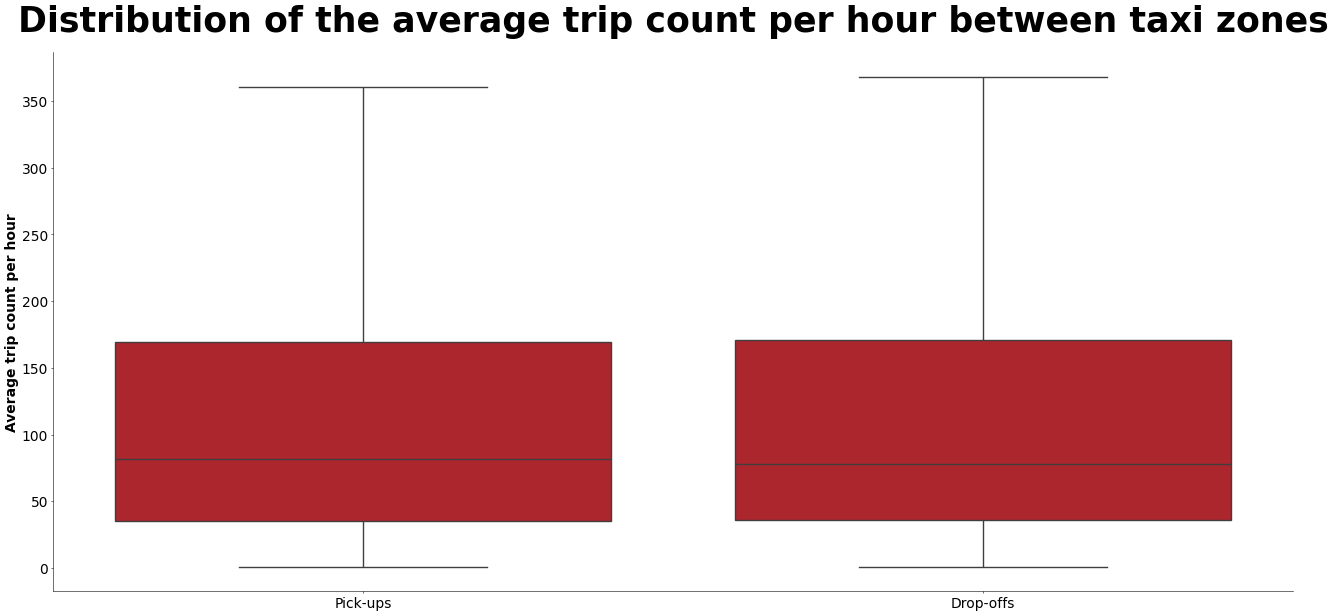

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------------------------------
# 1. Data Aggregation: Taxi Zone Trip Counts
# ---------------------------------------------------------
# Group by location IDs to calculate the average hourly trip counts for 
# pick-ups and drop-offs independently, then label and combine the sets.
# (AI generated)
taxiZones_PUs = PUs_df.groupby("PULocationID")["trip_count"].mean().reset_index()
taxiZones_DOs = DOs_df.groupby("DOLocationID")["trip_count"].mean().reset_index()

taxiZones_PUs["type"] = "Pick-ups"
taxiZones_DOs["type"] = "Drop-offs"

taxiZones_combined = pd.concat([taxiZones_PUs, taxiZones_DOs])

# ---------------------------------------------------------
# 2. Visualization: Zone Comparison Boxplot
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a boxplot comparing pick-up and drop-off trip count distributions.
sns.boxplot(
    data=taxiZones_combined,
    x="type",
    y="trip_count",
    color="#C21019",       
    linewidth=2,         
    showfliers=False  
)

# Set title and axes labels.
plt.title("Distribution of the average trip count per hour between taxi zones",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("", fontweight="bold")
plt.ylabel("Average trip count per hour", fontweight="bold")

# Export the high-resolution figure.
#plt.savefig("Plots/Distributions/TripCount/PUsandDOsperZoneBoxplot.png", dpi=300)
plt.show()

In [29]:
import geopandas as gpd

Map of the total trip count per taxi zone

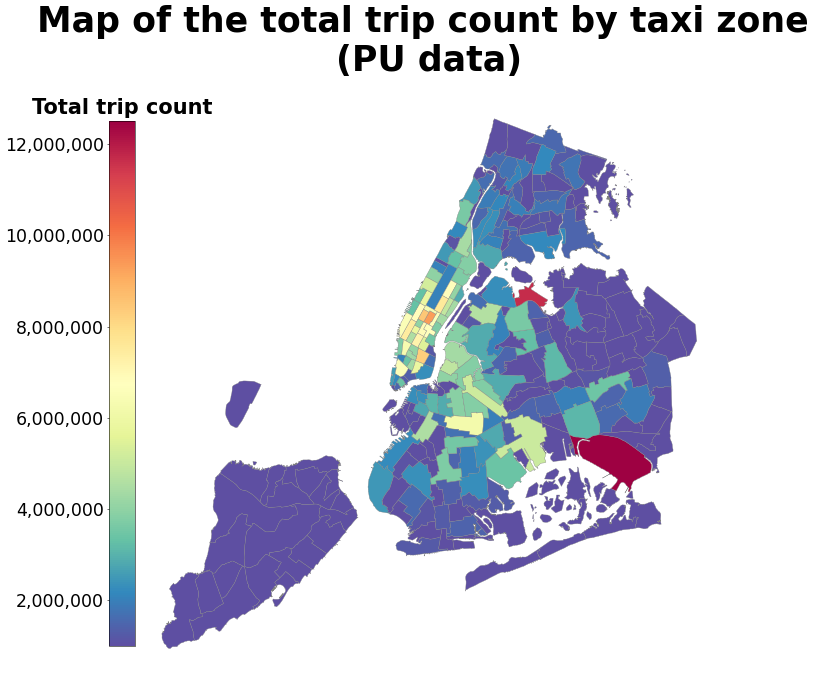

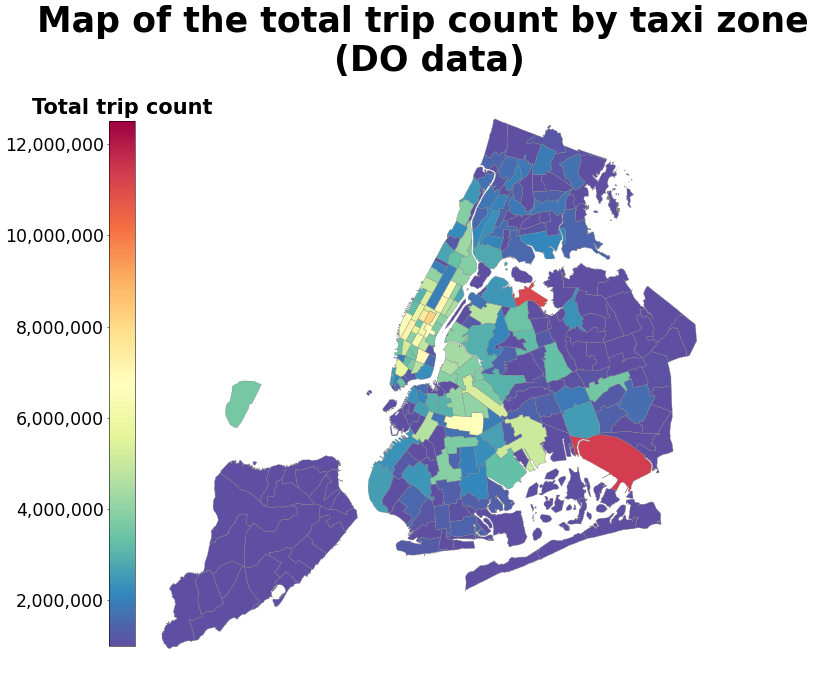

In [9]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Data Aggregation and Geopandas Merge
# ---------------------------------------------------------
# Load the taxi zones shapefile from the designated path.
zones = gpd.read_file(f"{path}/taxi_zones/taxi_zones.shp")

# Aggregate total trip counts per location ID and merge with the shapefile geometry.
# (AI generated)
trips_per_locationPUs = PUs_df.groupby("PULocationID")["trip_count"].sum().reset_index()
merged_PUs = zones.merge(trips_per_locationPUs, left_on="LocationID", right_on="PULocationID")

trips_per_locationDOs = DOs_df.groupby("DOLocationID")["trip_count"].sum().reset_index()
merged_DOs = zones.merge(trips_per_locationDOs, left_on="LocationID", right_on="DOLocationID")

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Geographic Map
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(32, 14))

merged_PUs.plot(
    column="trip_count",    
    cmap="Spectral_r",        
    linewidth=0.5,        
    ax=ax,                    
    edgecolor="0.5",
    vmin=1000000,
    vmax=12500000,          
    legend=True,              
    legend_kwds={
        "orientation": "vertical",
        "location": "left",
        "shrink": 0.9,
        "pad": 0
    }
)
ax.axis("off")

plt.title("Map of the total trip count by taxi zone \n(PU data)",
          fontsize=50, fontweight="bold", pad=30)

# Configure the colorbar formatting and labels.
cbar_ax = fig.axes[-1]
cbar_ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ","))) # AI generated
cbar_ax.set_title("Total trip count", pad=10, fontweight="bold", fontsize=30)
cbar_ax.tick_params(labelsize=25)

plt.tight_layout()


# plt.savefig("Plots/Distributions/TripCount/PUsTotalMap.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Geographic Map
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(32, 14))

merged_DOs.plot(
    column="trip_count",    
    cmap="Spectral_r",        
    linewidth=0.5,        
    ax=ax,                    
    edgecolor="0.5",
    vmin=1000000,
    vmax=12500000,          
    legend=True,              
    legend_kwds={ 
        "orientation": "vertical",
        "location": "left",
        "shrink": 0.9,
        "pad": 0
    }
)
ax.axis("off")

plt.title("Map of the total trip count by taxi zone \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)

# Configure the colorbar formatting and labels.
cbar_ax = fig.axes[-1]
cbar_ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))   # AI generated
cbar_ax.set_title("Total trip count", pad=10, fontweight="bold", fontsize=30)
cbar_ax.tick_params(labelsize=25)

plt.tight_layout()


# plt.savefig("Plots/Distributions/TripCount/DOsTotalMap.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Trip distance

Trip distance by day of week

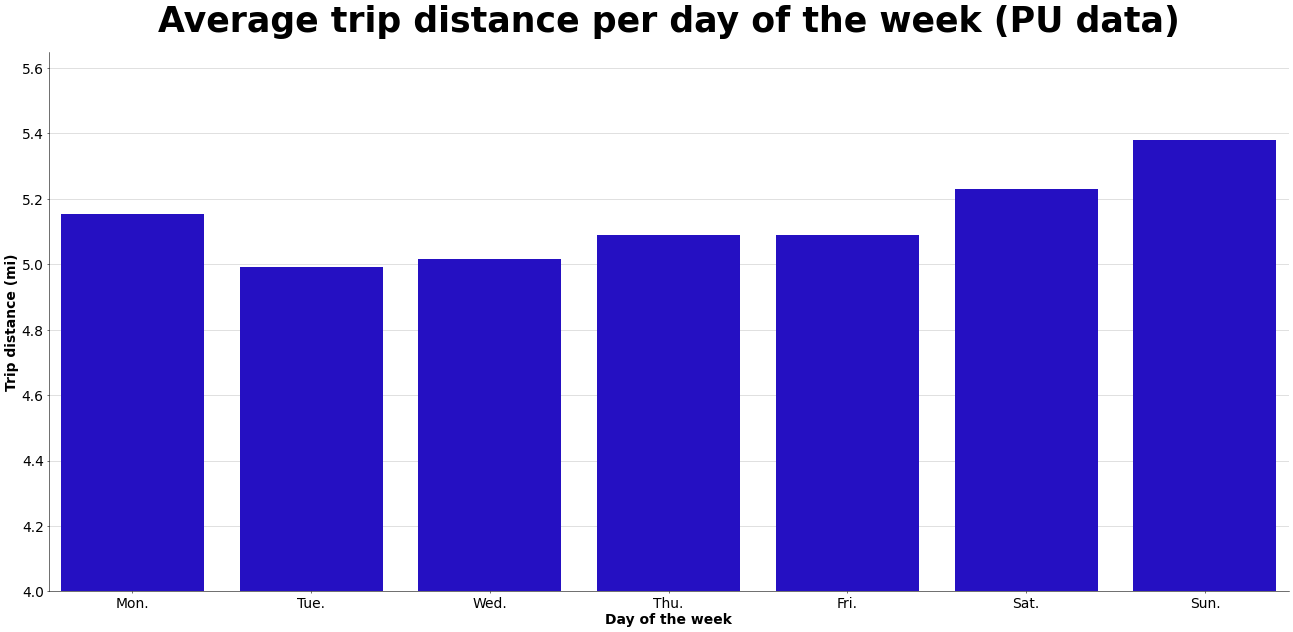

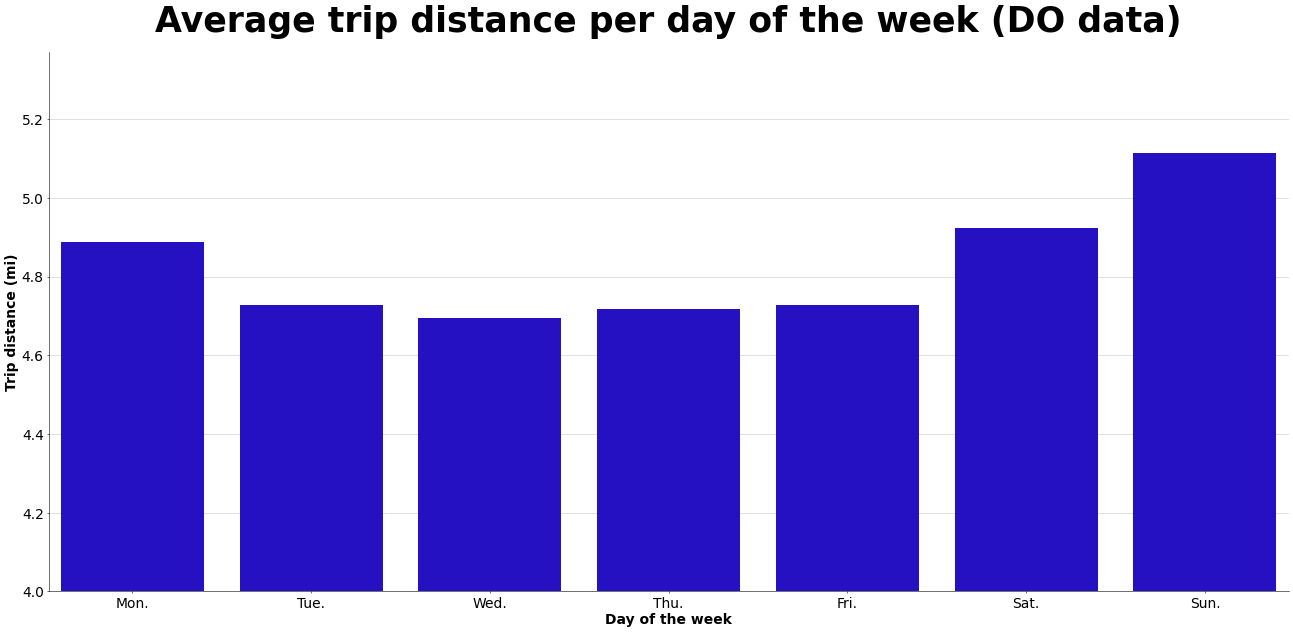

In [10]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Daily Average Trip Distance
# ---------------------------------------------------------
# Group the datasets by day of the week and calculate the mean trip distance.
daily_PUs = PUs_df.groupby("DayOfWeek")["trip_distance"].mean().reset_index()
daily_DOs = DOs_df.groupby("DayOfWeek")["trip_distance"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Daily Average Distance
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to average trip distances.
plt.bar(
    daily_PUs["DayOfWeek"],
    daily_PUs["trip_distance"],
    color="#2510C2"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip distance per day of the week (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip distance (mi)", fontweight="bold")
plt.margins(x=0.01)
plt.ylim(bottom=4)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# plt.savefig("Plots/Distributions/TripDistance/PUsDailyTripDistance.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Daily Average Distance
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to average trip distances.
plt.bar(
    daily_DOs["DayOfWeek"],
    daily_DOs["trip_distance"],
    color="#2510C2"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip distance per day of the week (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip distance (mi)", fontweight="bold")
plt.margins(x=0.01)
plt.ylim(bottom=4)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# plt.savefig("Plots/Distributions/TripDistance/DOsDailyTripDistance.png", dpi=300)
plt.show()

Trip distance per hour

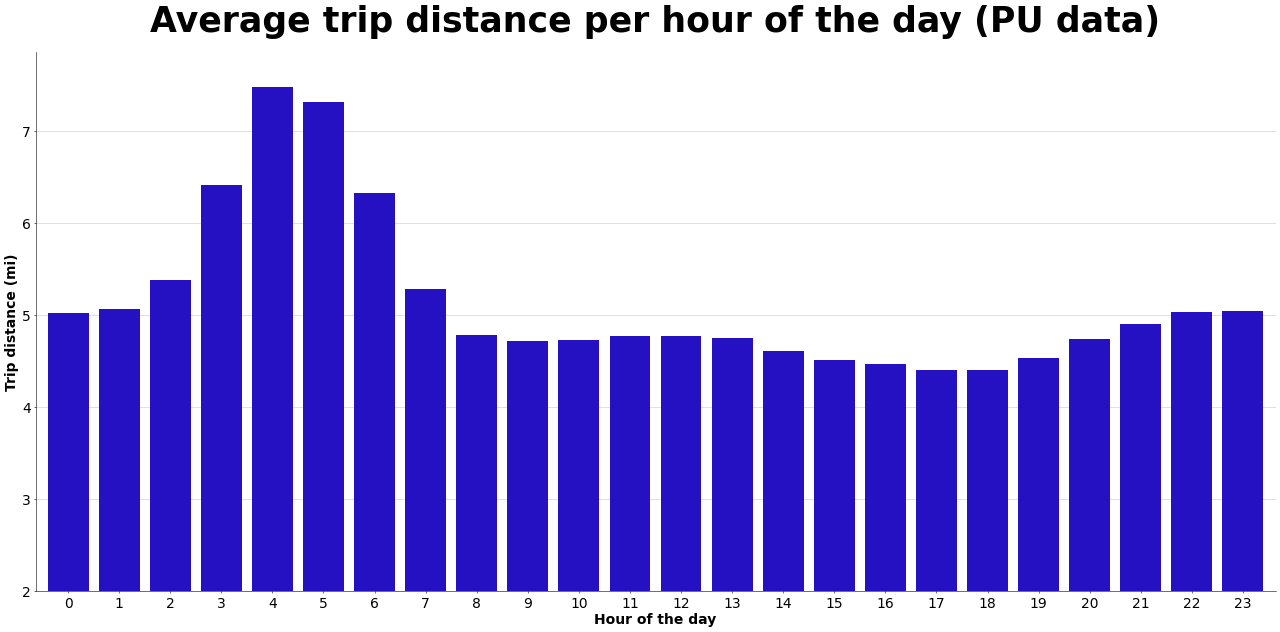

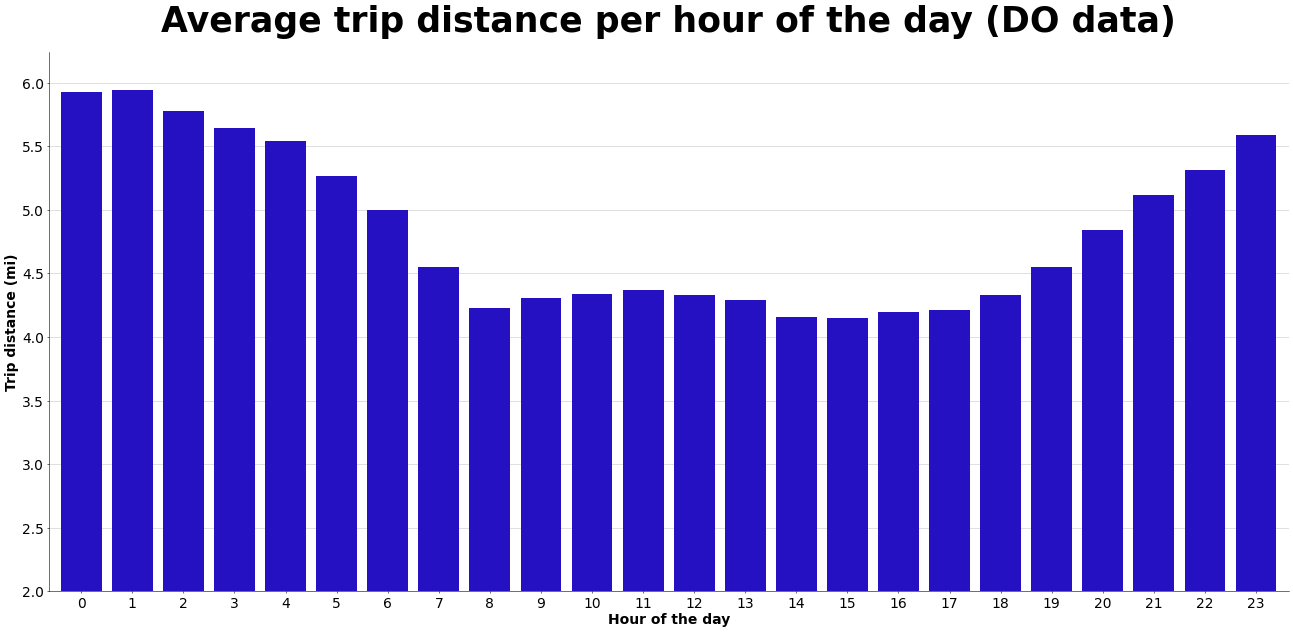

In [11]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Hourly Average Trip Distance
# ---------------------------------------------------------
# Group the datasets by hour of the day and calculate the mean trip distance.
hourly_PUs = PUs_df.groupby("hour")["trip_distance"].mean().reset_index()
hourly_DOs = DOs_df.groupby("hour")["trip_distance"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Hourly Average Distance
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to average trip distances.
plt.bar(
    hourly_PUs["hour"],
    hourly_PUs["trip_distance"],
    color="#2510C2"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip distance per hour of the day (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip distance (mi)", fontweight="bold")
plt.margins(x=0.01)
plt.ylim(bottom=2)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display the 24 hours.
plt.xticks(range(0, 24))

# plt.savefig("Plots/Distributions/TripDistance/PUsHourlyTripDistance.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Hourly Average Distance
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to average trip distances.
plt.bar(
    hourly_DOs["hour"],
    hourly_DOs["trip_distance"],
    color="#2510C2"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip distance per hour of the day (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip distance (mi)", fontweight="bold")
plt.margins(x=0.01)
plt.ylim(bottom=2)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display the 24 hours.
plt.xticks(range(0, 24))

# plt.savefig("Plots/Distributions/TripDistance/DOsHourlyTripDistance.png", dpi=300)
plt.show()

### Trip times

Distribution of trip times by hour

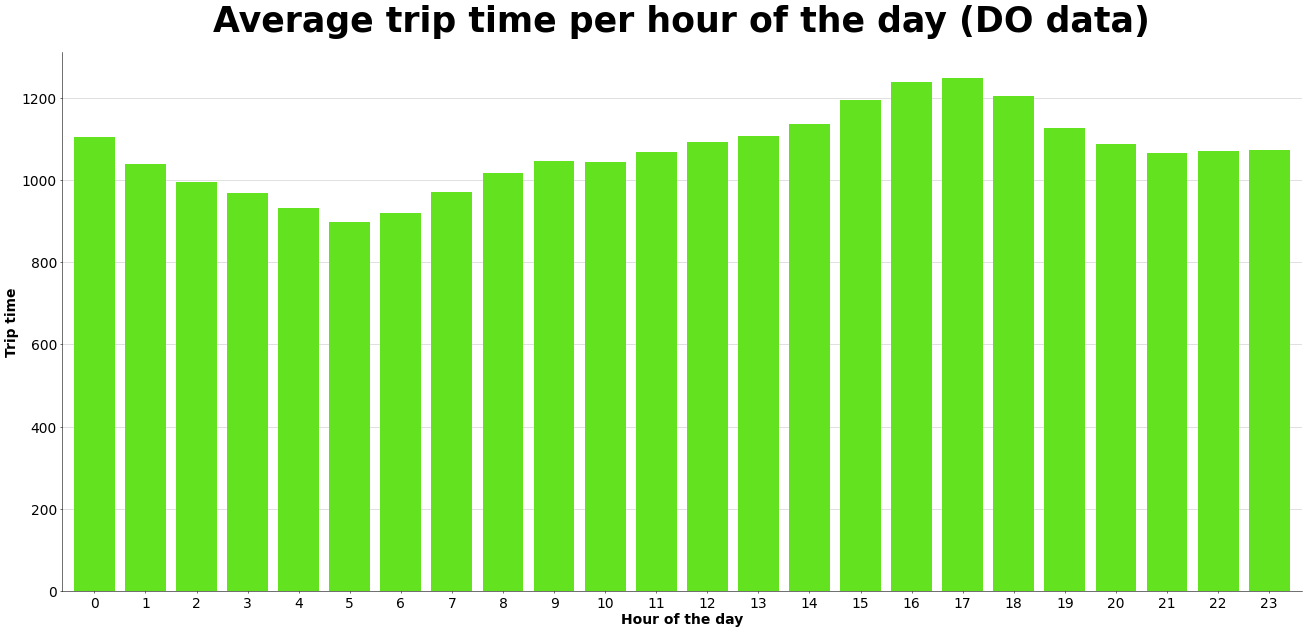

In [12]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Hourly Average Trip Time
# ---------------------------------------------------------
# Group the dataset by hour of the day and calculate the mean pickup-to-dropoff time.
hourly_DOs = DOs_df.groupby("hour")["pickup2dropoff"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Drop-Off (DO) Hourly Average Trip Time
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to average trip times.
plt.bar(
    hourly_DOs["hour"],
    hourly_DOs["pickup2dropoff"],
    color="#63E21F"
)

# Set title, axes labels, and margins to maintain consistent aesthetic formatting.
plt.title("Average trip time per hour of the day (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip time", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display the 24 hours.
plt.xticks(range(0, 24))

# plt.savefig("Plots/Distributions/TripTime/DOsHourlyTripTime.png", dpi=300)
plt.show()


Distribution of trip times by day of the week

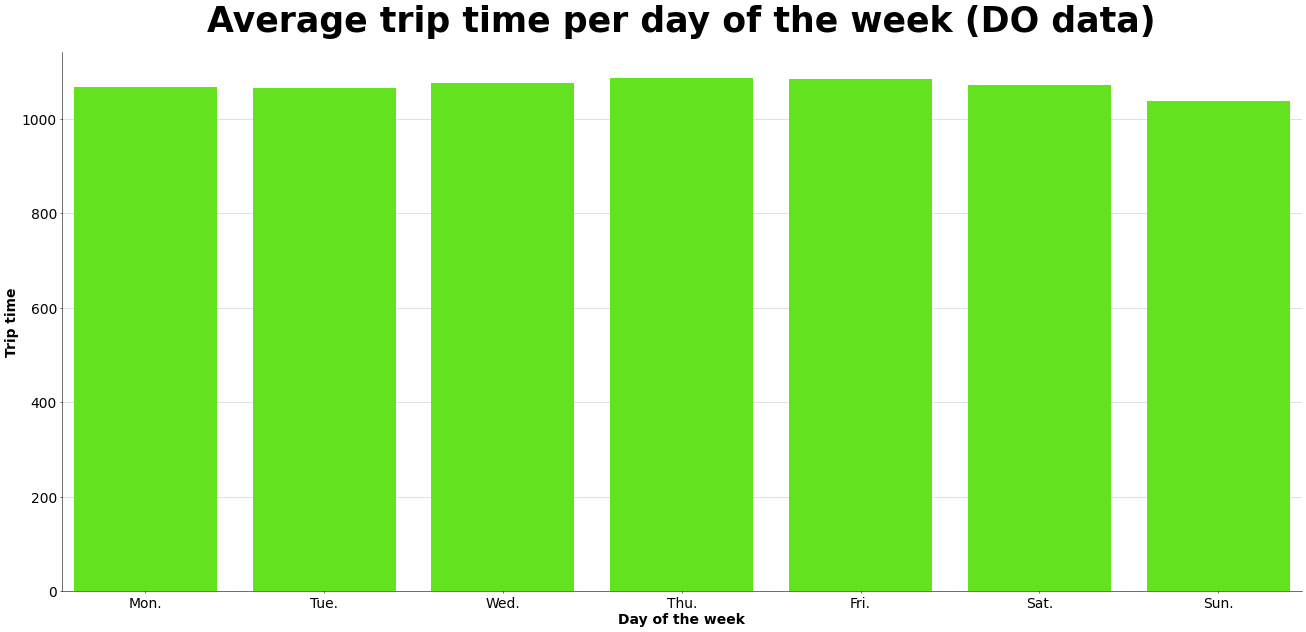

In [13]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Daily Average Trip Time
# ---------------------------------------------------------
# Group the dataset by day of the week and calculate the mean pickup-to-dropoff time.
daily_DOs = DOs_df.groupby("DayOfWeek")["pickup2dropoff"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Drop-Off (DO) Daily Average Trip Time
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to average trip times.
plt.bar(
    daily_DOs["DayOfWeek"],
    daily_DOs["pickup2dropoff"],
    color="#63E21F"
)

# Set title, axes labels, and margins to maintain consistent aesthetic formatting.
plt.title("Average trip time per day of the week (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip time", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# plt.savefig("Plots/Distributions/TripTime/DOsDailyTripTime.png", dpi=300)
plt.show()


In [14]:
# ---------------------------------------------------------
# 1. Outlier Detection: Negative Trip Times
# ---------------------------------------------------------
# Isolate records where the calculated trip time is less than zero 
# (e.g., drop-off timestamp is earlier than the pick-up timestamp).
negativeTripTimes = DOs_df[DOs_df["pickup2dropoff"] < 0]

# Output the total count of these anomalous records.
print(len(negativeTripTimes))

# Display the calculated trip time and drop-off hour for these specific records to inspect the issue.
print(negativeTripTimes[["pickup2dropoff", "DOhour"]])

# ---------------------------------------------------------
# 2. Data Clean-up and Filtering
# ---------------------------------------------------------
# Reassign the drop-off dataframe to strictly include valid, positive trip times.
DOs_df = DOs_df[DOs_df["pickup2dropoff"] > 0]

0
Empty DataFrame
Columns: [pickup2dropoff, DOhour]
Index: []


Trip time plots with cleaned data

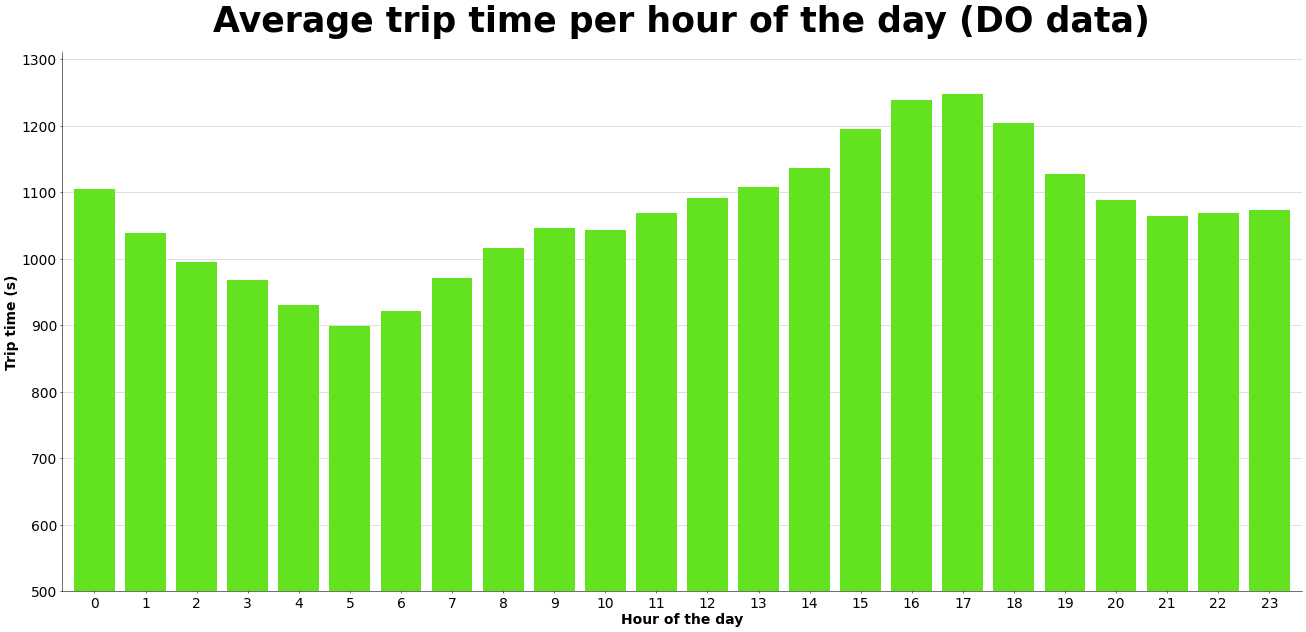

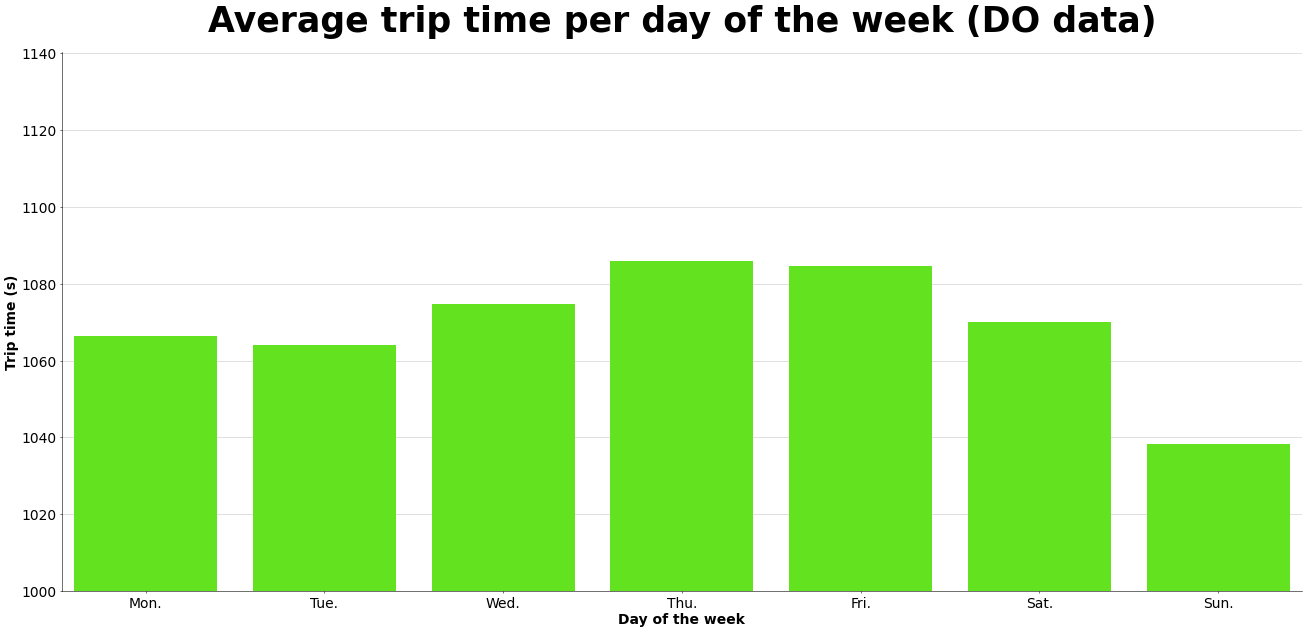

In [15]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Aggregation: Cleaned Hourly Average Trip Time
# ---------------------------------------------------------
# Group the filtered dataset by hour of the day and calculate the mean trip time.
hourly_DOs = DOs_df.groupby("hour")["pickup2dropoff"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Drop-Off (DO) Hourly Average Trip Time
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to average trip times.
plt.bar(
    hourly_DOs["hour"],
    hourly_DOs["pickup2dropoff"],
    color="#63E21F"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip time per hour of the day (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip time (s)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display the 24 hours.
plt.xticks(range(0, 24))
plt.ylim(bottom=500)

# plt.savefig("Plots/Distributions/TripTime/DOsHourlyTripTimeclean.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Data Aggregation: Cleaned Daily Average Trip Time
# ---------------------------------------------------------
# Group the filtered dataset by day of the week and calculate the mean trip time.
daily_DOs = DOs_df.groupby("DayOfWeek")["pickup2dropoff"].mean().reset_index()

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Daily Average Trip Time
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to average trip times.
plt.bar(
    daily_DOs["DayOfWeek"],
    daily_DOs["pickup2dropoff"],
    color="#63E21F"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip time per day of the week (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip time (s)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])
plt.ylim(bottom=1000)

# plt.savefig("Plots/Distributions/TripTime/DOsDailyTripTimeclean.png", dpi=300)
plt.show()


### Trip time divided by trip distance (congestion)

Hourly distribution of trip time (PU2DO) divided by trip distance

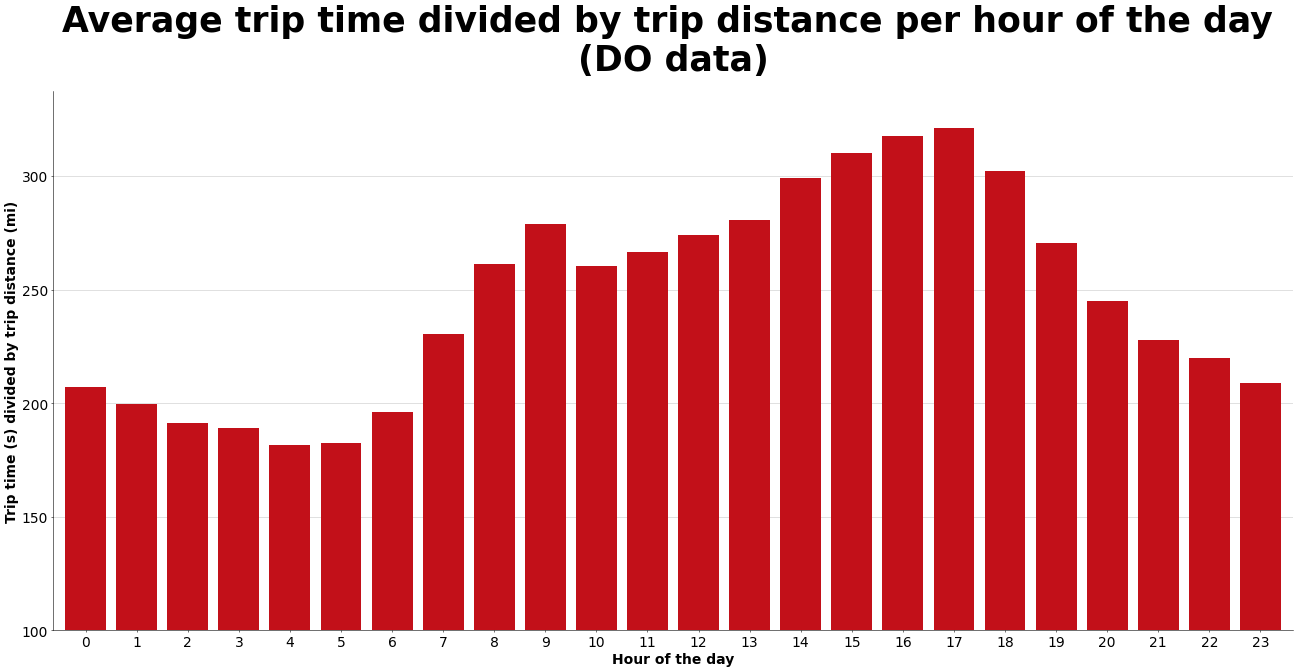

In [16]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Feature Engineering: Congestion Index Calculation
# ---------------------------------------------------------
# Calculate a proxy for congestion by dividing trip time (seconds) by trip distance (miles).
DOs_df["congestion_index"] = DOs_df["pickup2dropoff"] / DOs_df["trip_distance"]

# Group the dataset by hour of the day and calculate the mean congestion index.
hourly_DOs = DOs_df.groupby("hour")["congestion_index"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Drop-Off (DO) Hourly Congestion
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the 24-hour cycle to the average congestion index.
plt.bar(
    hourly_DOs["hour"],
    hourly_DOs["congestion_index"],
    color="#C21019"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip time divided by trip distance per hour of the day \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold")
plt.ylabel("Trip time (s) divided by trip distance (mi)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display the 24 hours.
plt.xticks(range(0, 24))
plt.ylim(bottom=100)

# plt.savefig("Plots/Distributions/Congestion/DOsHourlyCongestion.png", dpi=300)
plt.show()

Daily distribution of trip time (PU2DO) divided by trip distance

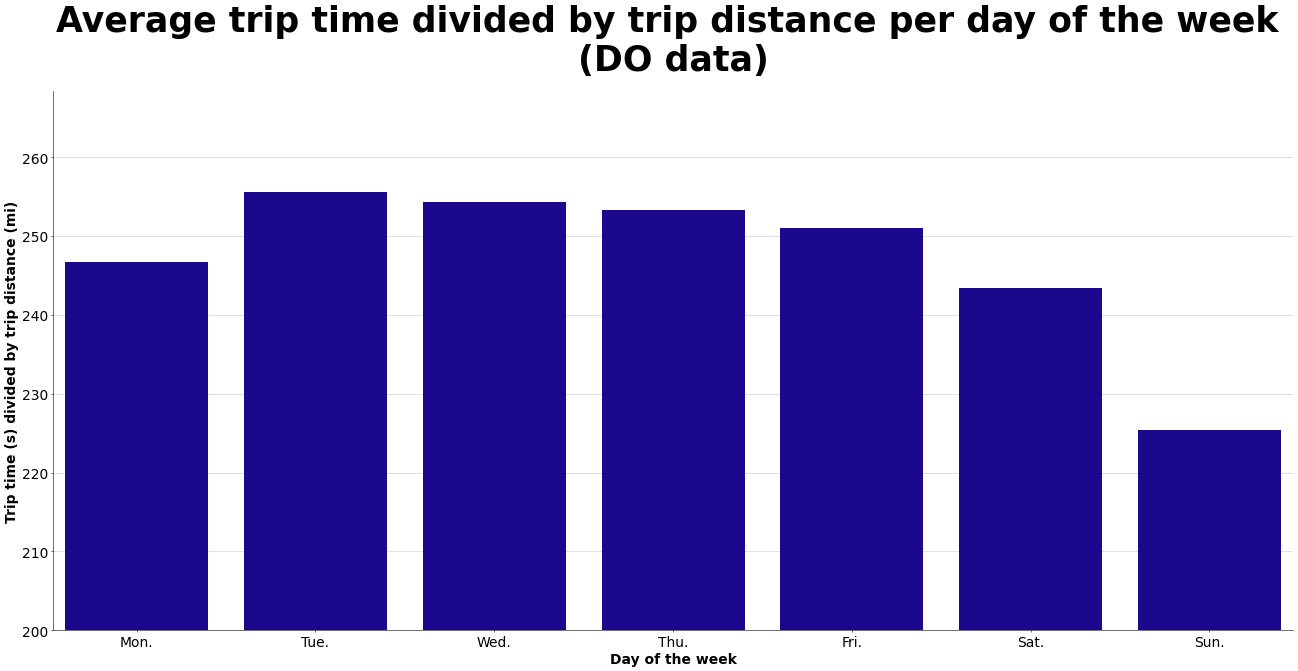

In [17]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Feature Engineering & Data Aggregation: Daily Congestion
# ---------------------------------------------------------
# Calculate the congestion index (trip time divided by trip distance).
DOs_df["congestion_index"] = DOs_df["pickup2dropoff"] / DOs_df["trip_distance"]

# Group the dataset by day of the week and calculate the mean congestion index.
daily_DOs = DOs_df.groupby("DayOfWeek")["congestion_index"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Drop-Off (DO) Daily Congestion
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to the average congestion index.
plt.bar(
    daily_DOs["DayOfWeek"],
    daily_DOs["congestion_index"],
    color="#1A098D"
)

# Set title, axes labels, margins, and lower limits.
plt.title("Average trip time divided by trip distance per day of the week \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Trip time (s) divided by trip distance (mi)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])
plt.ylim(bottom=200)

# plt.savefig("Plots/Distributions/Congestion/DOsDailyCongestion.png", dpi=300)
plt.show()

### Fare, tip and total amounts paid

Fare amount, tip amount and total amount by hour of the day

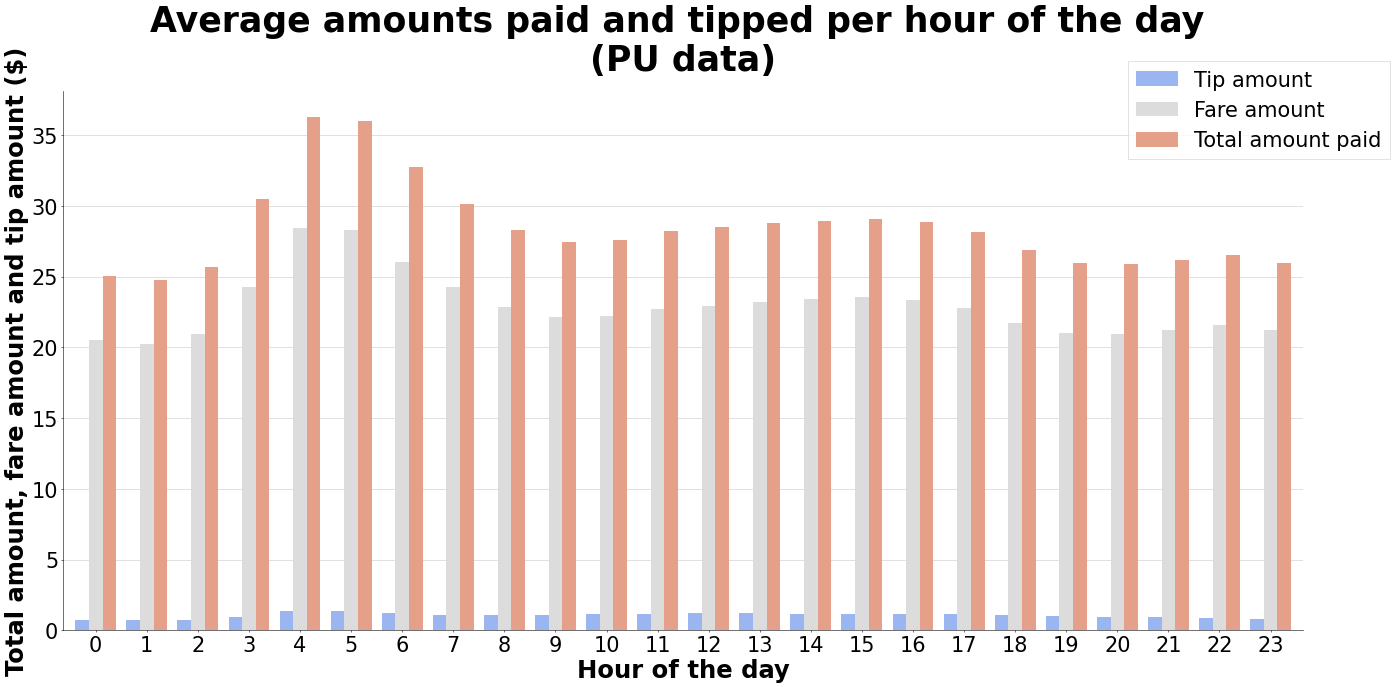

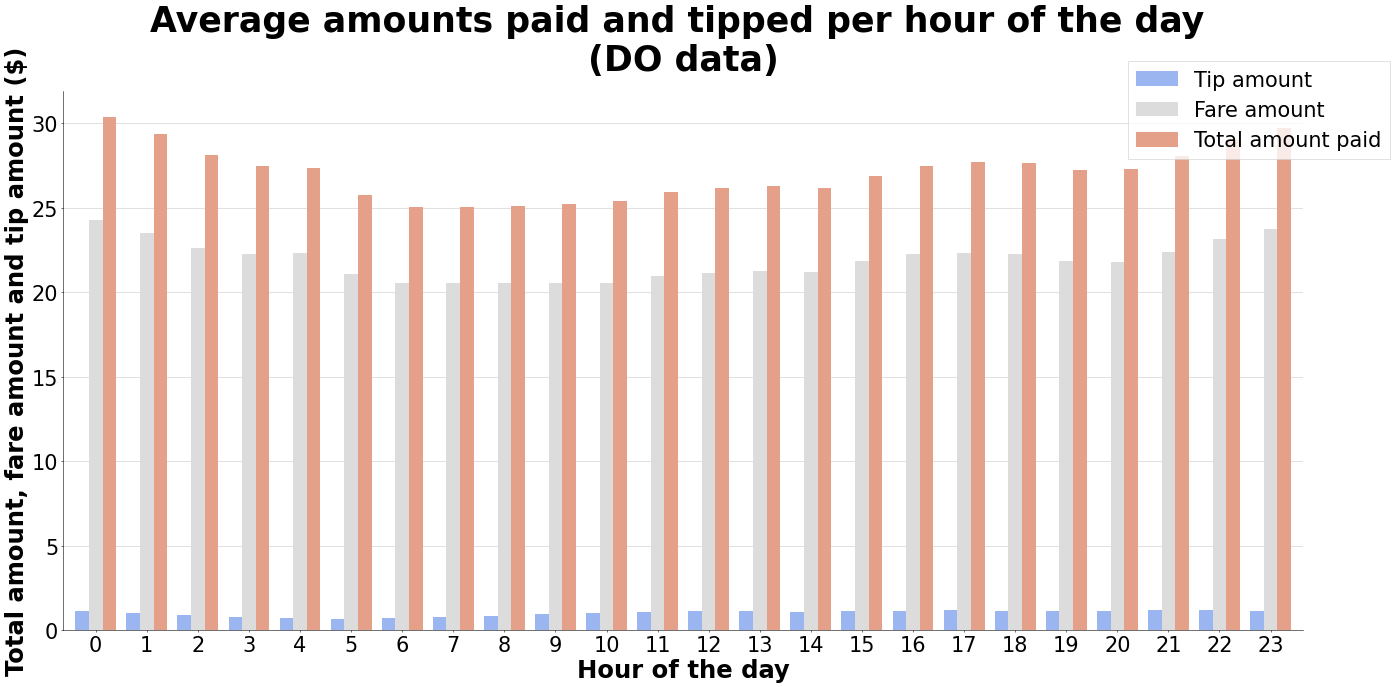

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Data Transformation: Pick-Up (PU) Amounts
# ---------------------------------------------------------
# Melt the dataframe to a long format suitable for grouped bar plotting.
# (AI generated)
hourly_PUs_melted = PUs_df.melt(
    id_vars="hour",
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="Feature",
    value_name="Value"
)

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Hourly Amounts
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a grouped bar chart mapping the 24-hour cycle to financial metrics.
sns.barplot(
    data=hourly_PUs_melted, 
    x="hour", 
    y="Value", 
    hue="Feature",
    errorbar=None,
    palette="coolwarm"
)

# Configure a custom legend positioned outside the main plot area.
plt.legend(
    title="",
    loc="upper left",
    bbox_to_anchor=(0.85, 1.075),
    fancybox=False,
    labels=["Tip amount", "Fare amount", "Total amount paid"],
    fontsize=30
)

# Set titles, axes labels, and formatting.
plt.title("Average amounts paid and tipped per hour of the day \n(PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold", fontsize=35)
plt.ylabel("Total amount, fare amount and tip amount ($)", fontweight="bold", fontsize=35)
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format axes ticks.
plt.xticks(range(0, 24), fontsize=30)
plt.yticks(fontsize=30)

# plt.savefig("Plots/Distributions/Amounts/PUsHourlyAmounts.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 3. Data Transformation: Drop-Off (DO) Amounts
# ---------------------------------------------------------
# Melt the dataframe to a long format suitable for grouped bar plotting.
# (AI generated)
hourly_DOs_melted = DOs_df.melt(
    id_vars="hour",
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="Feature",
    value_name="Value"
)

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Hourly Amounts
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a grouped bar chart mapping the 24-hour cycle to financial metrics.
sns.barplot(
    data=hourly_DOs_melted, 
    x="hour", 
    y="Value", 
    hue="Feature",
    errorbar=None,
    palette="coolwarm"
)

# Configure a custom legend positioned outside the main plot area.
plt.legend(
    title="",
    loc="upper left",
    bbox_to_anchor=(0.85, 1.075),
    fancybox=False,
    labels=["Tip amount", "Fare amount", "Total amount paid"],
    fontsize=30
)

# Set titles, axes labels, and formatting.
plt.title("Average amounts paid and tipped per hour of the day \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold", fontsize=35)
plt.ylabel("Total amount, fare amount and tip amount ($)", fontweight="bold", fontsize=35)
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format axes ticks.
plt.xticks(range(0, 24), fontsize=30)
plt.yticks(fontsize=30)

# plt.savefig("Plots/Distributions/Amounts/DOsHourlyAmounts.pdf", dpi=300, bbox_inches="tight")
plt.show()

Fare amount, tip amount and total amount by day of week

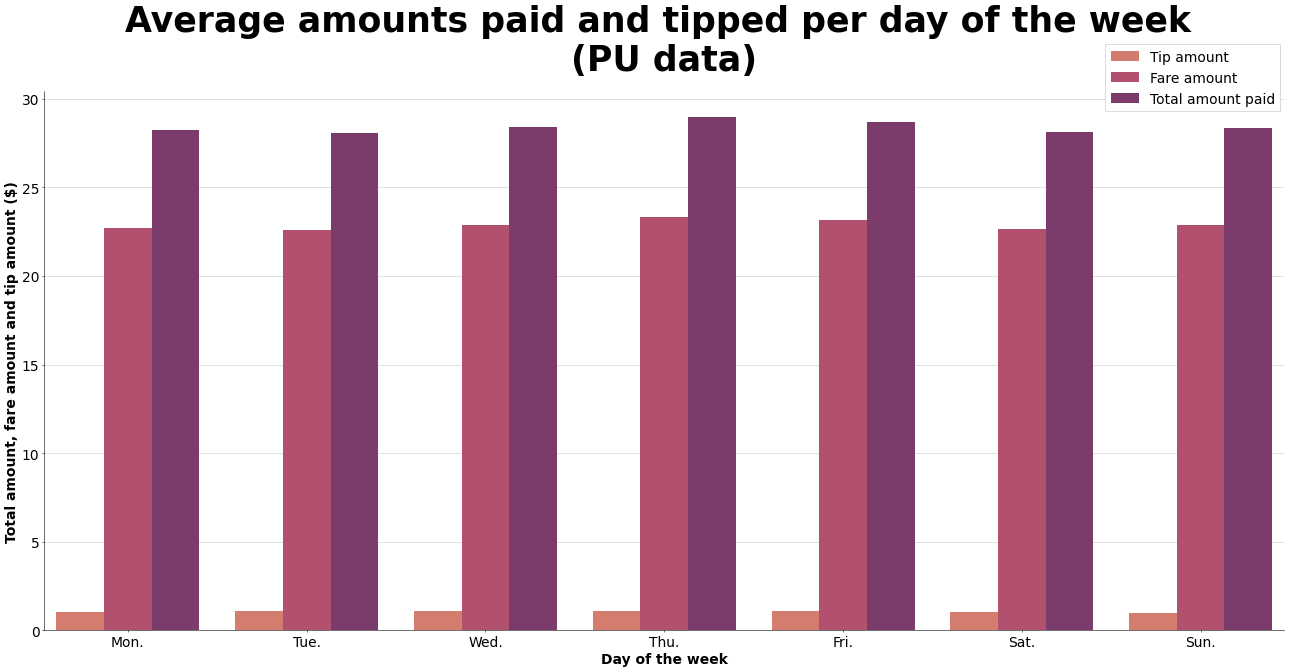

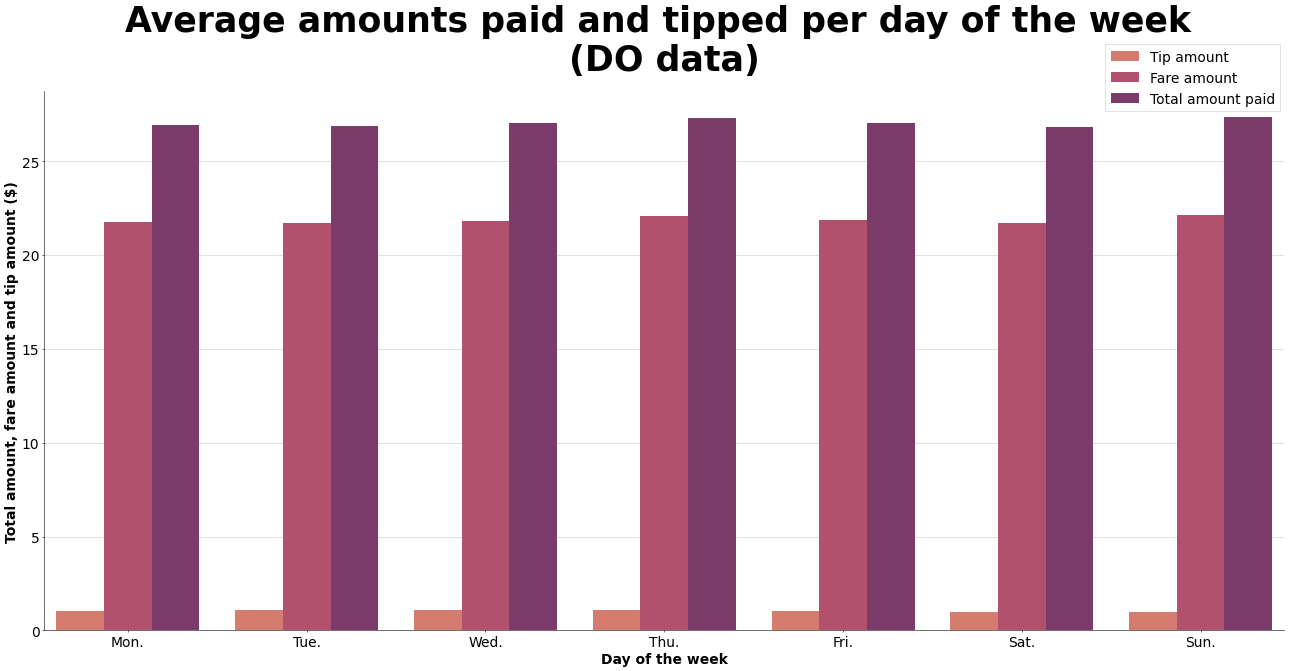

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Data Transformation: Pick-Up (PU) Daily Amounts
# ---------------------------------------------------------
# Melt the dataframe to a long format suitable for grouped bar plotting.
# (AI generated)
daily_PUs_melted = PUs_df.melt(
    id_vars="DayOfWeek",
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="Feature",
    value_name="Value"
)

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Daily Amounts
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a grouped bar chart mapping the day of the week to financial metrics.
sns.barplot(
    data=daily_PUs_melted, 
    x="DayOfWeek", 
    y="Value", 
    hue="Feature",
    errorbar=None,
    palette="flare"
)

# Configure a custom legend positioned outside the main plot area.
plt.legend(
    title="",
    loc="upper left",
    bbox_to_anchor=(0.85, 1.1),
    fancybox=False,
    framealpha=1,
    labels=["Tip amount", "Fare amount", "Total amount paid"]
)

# Set titles, axes labels, and formatting.
plt.title("Average amounts paid and tipped per day of the week \n(PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Total amount, fare amount and tip amount ($)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# plt.savefig("Plots/Distributions/Amounts/PUsDailyAmounts.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Data Transformation: Drop-Off (DO) Daily Amounts
# ---------------------------------------------------------
# Melt the dataframe to a long format suitable for grouped bar plotting.
# (AI generated)
daily_DOs_melted = DOs_df.melt(
    id_vars="DayOfWeek",
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="Feature",
    value_name="Value"
)

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Daily Amounts
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a grouped bar chart mapping the day of the week to financial metrics.
sns.barplot(
    data=daily_DOs_melted, 
    x="DayOfWeek", 
    y="Value", 
    hue="Feature",
    errorbar=None,
    palette="flare"
)

# Configure a custom legend positioned outside the main plot area.
plt.legend(
    title="",
    loc="upper left",
    bbox_to_anchor=(0.85, 1.1),
    fancybox=False,
    labels=["Tip amount", "Fare amount", "Total amount paid"]
)

# Set titles, axes labels, and formatting.
plt.title("Average amounts paid and tipped per day of the week \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Total amount, fare amount and tip amount ($)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# plt.savefig("Plots/Distributions/Amounts/DOsDailyAmounts.png", dpi=300)
plt.show()

Fare amount, tip amount and total amount by day of week with holidays as a seperate category

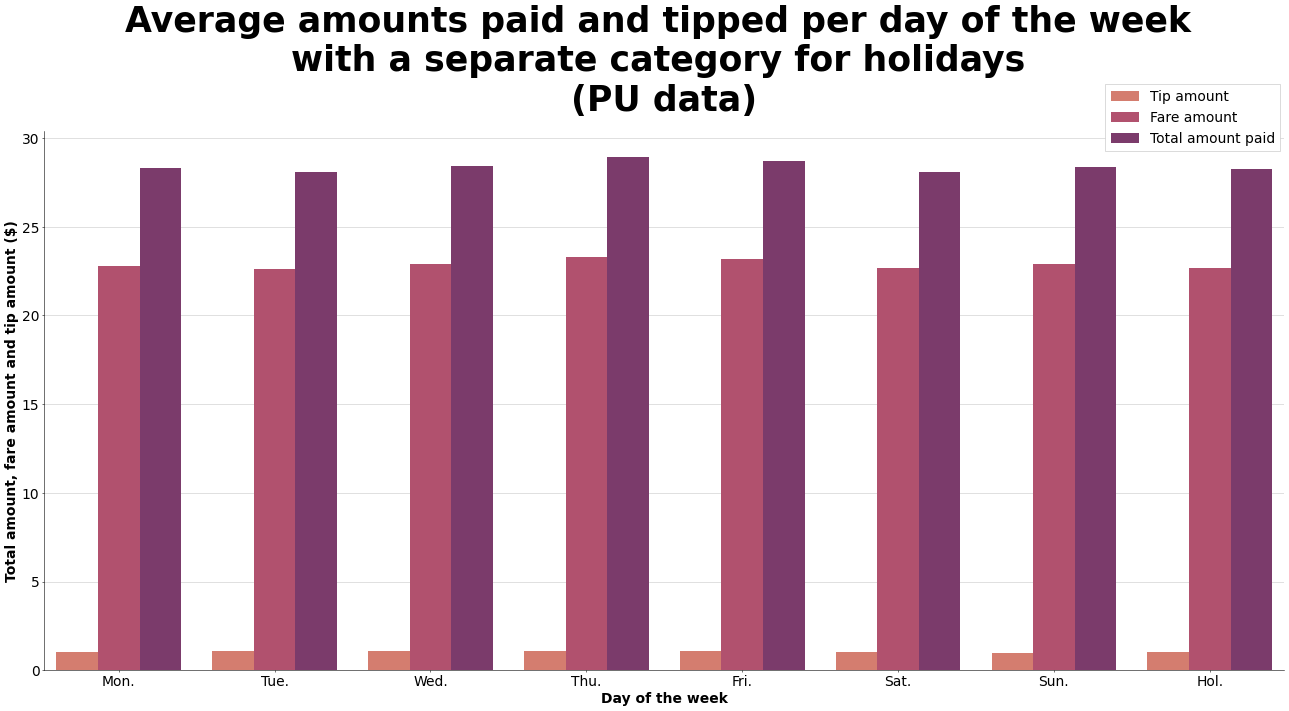

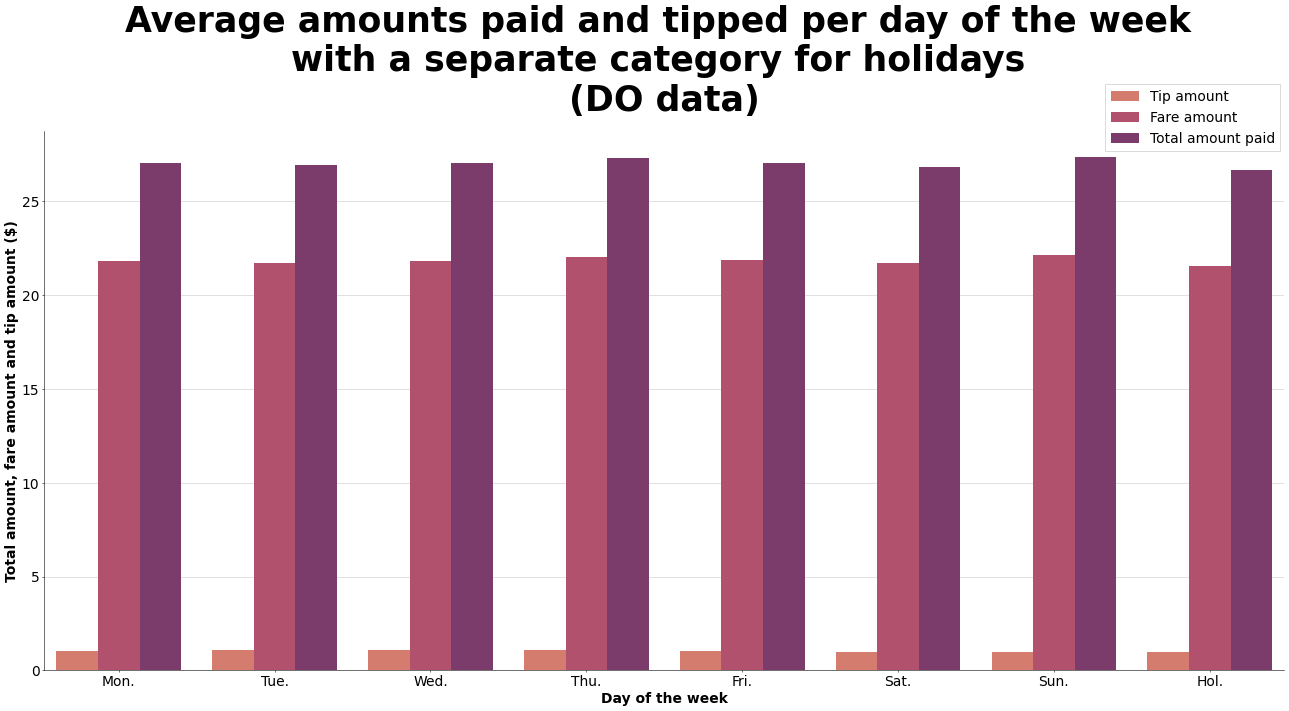

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Data Transformation: Pick-Up (PU) Holiday Grouping & Melting
# ---------------------------------------------------------
# Map numerical day indicators to explicit strings.
# (AI generated)
day_mapping = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday",
    3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"
}

PUs_df["day"] = PUs_df["DayOfWeek"].map(day_mapping) # AI generated

# Create a distinct category for recognized holidays.
PUs_df["day_group"] = np.where(PUs_df["is_holiday"] == True, "Holiday", PUs_df["day"]) # AI generated

# Melt the dataframe to group financial metrics by the new day_group feature.
# (AI generated)
daily_df = PUs_df.melt(
    id_vars="day_group",
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="Feature",
    value_name="Value"
)

# Establish a strict sorting order to ensure 'Holiday' renders at the far right.
# (AI generated)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "Holiday"]
daily_df["day_group"] = pd.Categorical(daily_df["day_group"], categories=day_order, ordered=True)
grouped_df = daily_df.sort_values("day_group")

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Holiday Financials
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a grouped bar chart mapping the customized day groups to financial metrics.
sns.barplot(
    data=daily_df, 
    x="day_group", 
    y="Value", 
    hue="Feature",
    errorbar=None,
    palette="flare"
)

# Configure a custom legend positioned outside the main plot area.
plt.legend(
    title="",
    loc="upper left",
    bbox_to_anchor=(0.85, 1.1),
    fancybox=False,
    framealpha=1,
    labels=["Tip amount", "Fare amount", "Total amount paid"]
)

# Set titles, axes labels, and formatting.
plt.title("Average amounts paid and tipped per day of the week \nwith a separate category for holidays \n(PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Total amount, fare amount and tip amount ($)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to include the holiday bin.
plt.xticks(range(0, 8), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun.", "Hol."])

# plt.savefig("Plots/Distributions/Amounts/PUsDailyHolidayAmounts.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Data Transformation: Drop-Off (DO) Holiday Grouping & Melting
# ---------------------------------------------------------
# Apply the exact same mapping, grouping, and melting transformations to the Drop-Off dataset.
# (AI generated)
DOs_df["day"] = DOs_df["DayOfWeek"].map(day_mapping)
DOs_df["day_group"] = np.where(DOs_df["is_holiday"] == True, "Holiday", DOs_df["day"])

daily_df = DOs_df.melt(
    id_vars="day_group",
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="Feature",
    value_name="Value"
)

daily_df["day_group"] = pd.Categorical(daily_df["day_group"], categories=day_order, ordered=True)
grouped_df = daily_df.sort_values("day_group")

# ---------------------------------------------------------
# 4. Visualization: Drop-Off (DO) Holiday Financials
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a grouped bar chart mapping the customized day groups to financial metrics.
sns.barplot(
    data=daily_df, 
    x="day_group", 
    y="Value", 
    hue="Feature",
    errorbar=None,
    palette="flare"
)

# Configure a custom legend positioned outside the main plot area.
plt.legend(
    title="",
    loc="upper left",
    bbox_to_anchor=(0.85, 1.1),
    fancybox=False,
    framealpha=1,
    labels=["Tip amount", "Fare amount", "Total amount paid"]
)

# Set titles, axes labels, and formatting.
plt.title("Average amounts paid and tipped per day of the week \nwith a separate category for holidays \n(DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Total amount, fare amount and tip amount ($)", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to include the holiday bin.
plt.xticks(range(0, 8), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun.", "Hol."])

# plt.savefig("Plots/Distributions/Amounts/DOsDailyHolidayAmounts.png", dpi=300)
plt.show()

### Percentages of For-hire Vehicles

Percentage of FHVHV by day of week

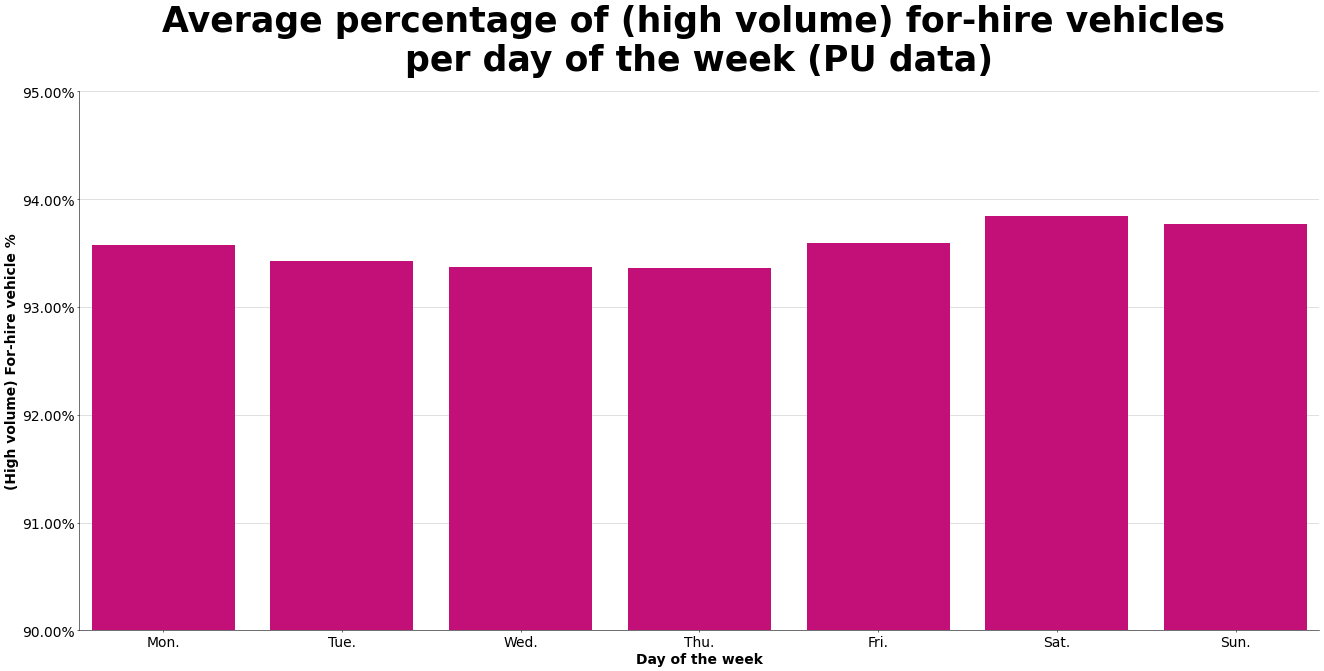

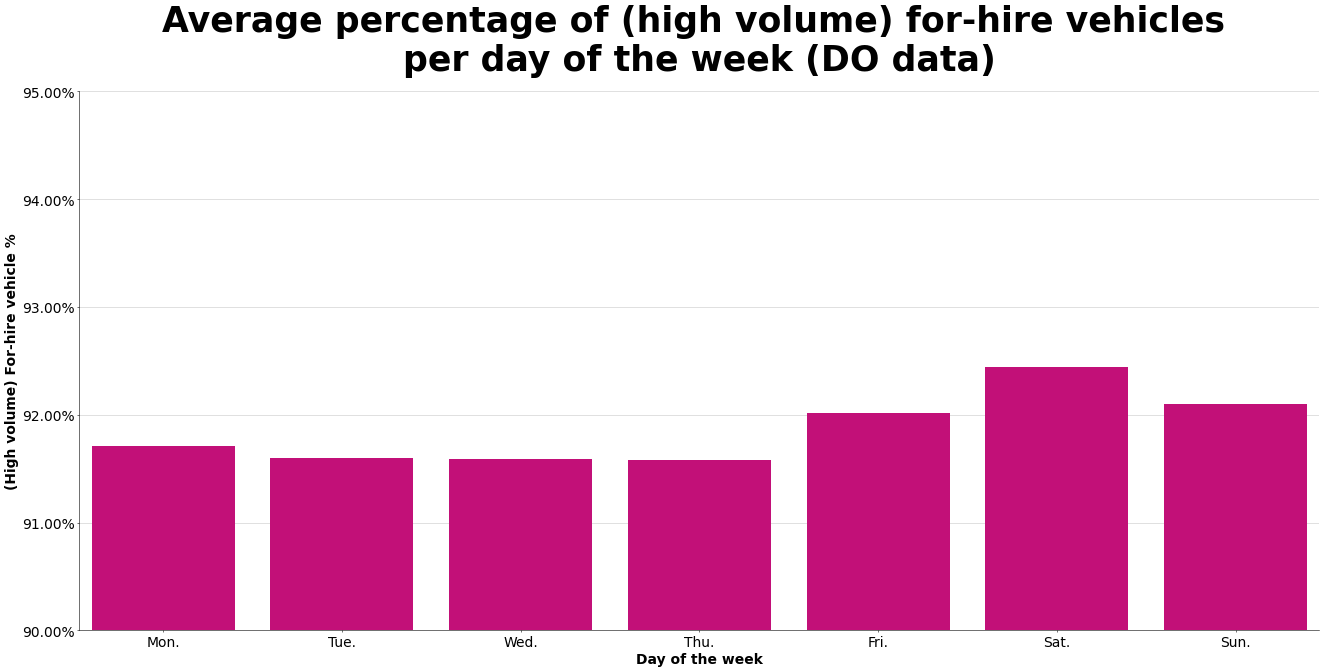

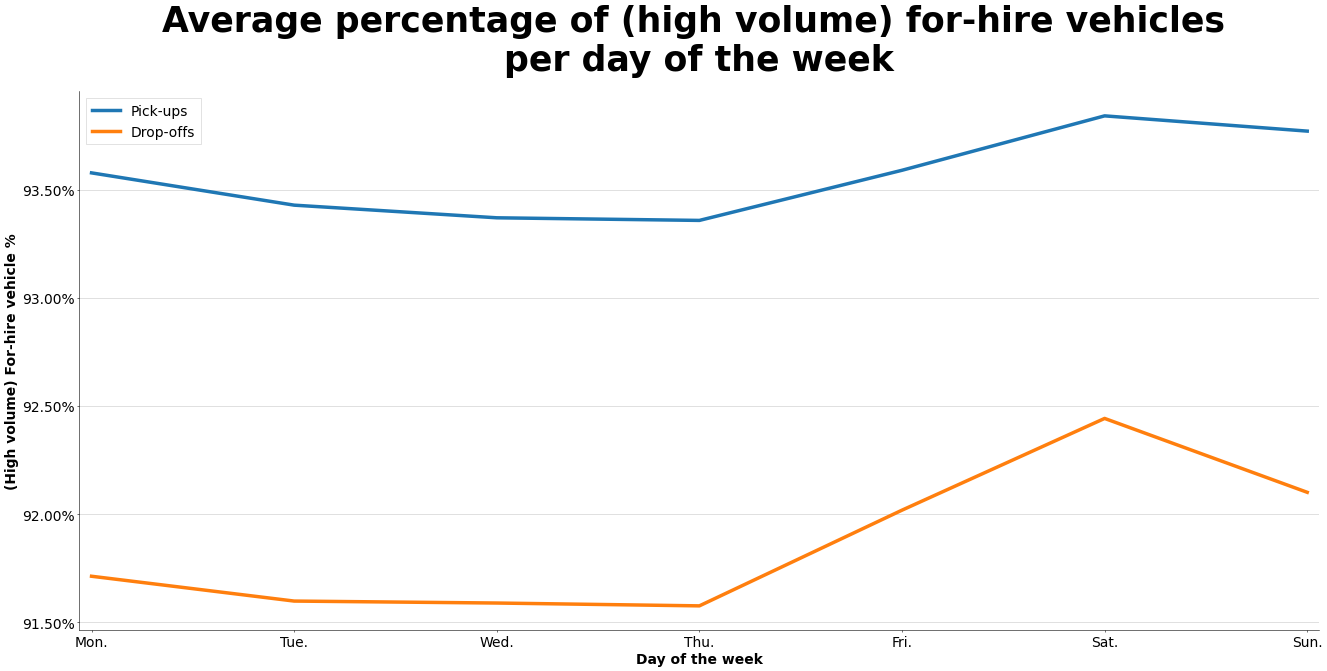

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Data Aggregation: Daily Average FHVHV Percentage
# ---------------------------------------------------------
# Group the datasets by day of the week and calculate the mean percentage 
# of high-volume for-hire vehicles.
daily_PUs = PUs_df.groupby("DayOfWeek")["fhvhv_percentage"].mean().reset_index()
daily_DOs = DOs_df.groupby("DayOfWeek")["fhvhv_percentage"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Daily FHVHV Percentage (Bar)
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to the FHVHV percentage.
plt.bar(
    daily_PUs["DayOfWeek"],
    daily_PUs["fhvhv_percentage"],
    color="#C21078"
)

# Set title, axes labels, and formatting.
plt.title("Average percentage of (high volume) for-hire vehicles \nper day of the week (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("(High volume) For-hire vehicle %", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# Constrain the y-axis to highlight variances and format as percentages.
plt.ylim(0.9, 0.95)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0)) # AI generated

# plt.savefig("Plots/Distributions/FHVHV/PUsDailyFHVHV.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Daily FHVHV Percentage (Bar)
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a bar chart mapping the day of the week to the FHVHV percentage.
plt.bar(
    daily_DOs["DayOfWeek"],
    daily_DOs["fhvhv_percentage"],
    color="#C21078"
)

# Set title, axes labels, and formatting.
plt.title("Average percentage of (high volume) for-hire vehicles \nper day of the week (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("(High volume) For-hire vehicle %", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the bar elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# Constrain the y-axis to highlight variances and format as percentages.
plt.ylim(0.9, 0.95)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0)) # AI generated

# plt.savefig("Plots/Distributions/FHVHV/DOsDailyFHVHV.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 4. Visualization: Pick-Up vs Drop-Off Comparison (Line)
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate line plots to overlay and compare the PU and DO percentages.
sns.lineplot(data=daily_PUs, x="DayOfWeek", y="fhvhv_percentage", linewidth=5)
sns.lineplot(data=daily_DOs, x="DayOfWeek", y="fhvhv_percentage", linewidth=5)

# Set title, axes labels, and formatting.
plt.title("Average percentage of (high volume) for-hire vehicles \nper day of the week",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("(High volume) For-hire vehicle %", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the line elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0)) # AI generated

# Extract the drawn lines to construct a custom legend.
lines = plt.gca().get_lines()
plt.legend(handles=lines, labels=["Pick-ups", "Drop-offs"], fancybox=False)

# plt.savefig("Plots/Distributions/FHVHV/PUsandDOsDailyFHVHVline.png", dpi=300)
plt.show()

Percentage of FHVHV by hour

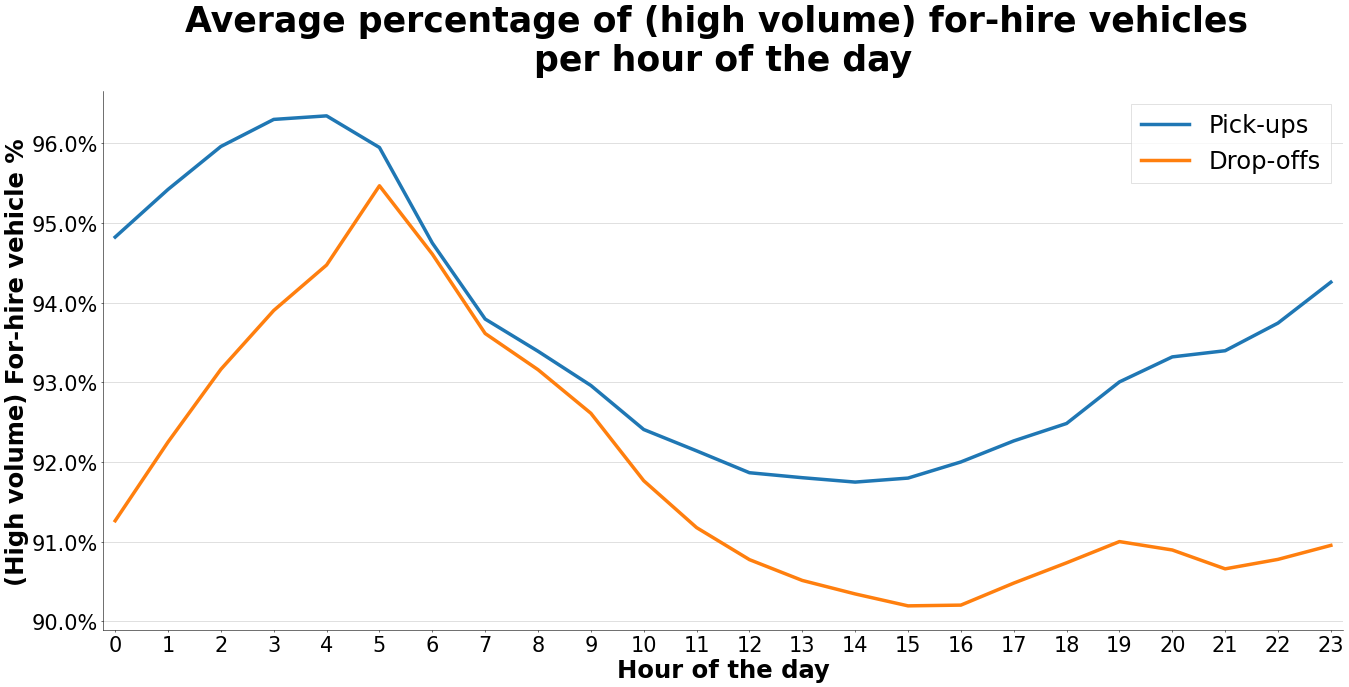

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Data Aggregation: Hourly Average FHVHV Percentage
# ---------------------------------------------------------
# Group the datasets by hour of the day and calculate the mean percentage 
# of high-volume for-hire vehicles.
hourly_PUs = PUs_df.groupby("hour")["fhvhv_percentage"].mean().reset_index()
hourly_DOs = DOs_df.groupby("hour")["fhvhv_percentage"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up vs Drop-Off Hourly Comparison
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate line plots to overlay and compare the PU and DO percentages.
sns.lineplot(data=hourly_PUs, x="hour", y="fhvhv_percentage", linewidth=5)
sns.lineplot(data=hourly_DOs, x="hour", y="fhvhv_percentage", linewidth=5)

# Set titles, axes labels, and formatting. 
# (Corrected the y-label to reflect FHVHV metric instead of financial amounts)
plt.title("Average percentage of (high volume) for-hire vehicles \nper hour of the day",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Hour of the day", fontweight="bold", fontsize=35)
plt.ylabel("(High volume) For-hire vehicle %", fontweight="bold", fontsize=35)
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the line elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format axes ticks and convert the y-axis values to percentages.
plt.xticks(range(0, 24), fontsize=30)
plt.yticks(fontsize=30)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

# Extract the drawn lines to construct a custom legend.
lines = plt.gca().get_lines()
plt.legend(handles=lines, labels=["Pick-ups", "Drop-offs"], fancybox=False, fontsize=35)

# plt.savefig("Plots/Distributions/FHVHV/PUsandDOsHourlyFHVHVline.pdf", dpi=300, bbox_inches="tight")
plt.show()


Distribution of total FHVHV percentages across the taxi zones

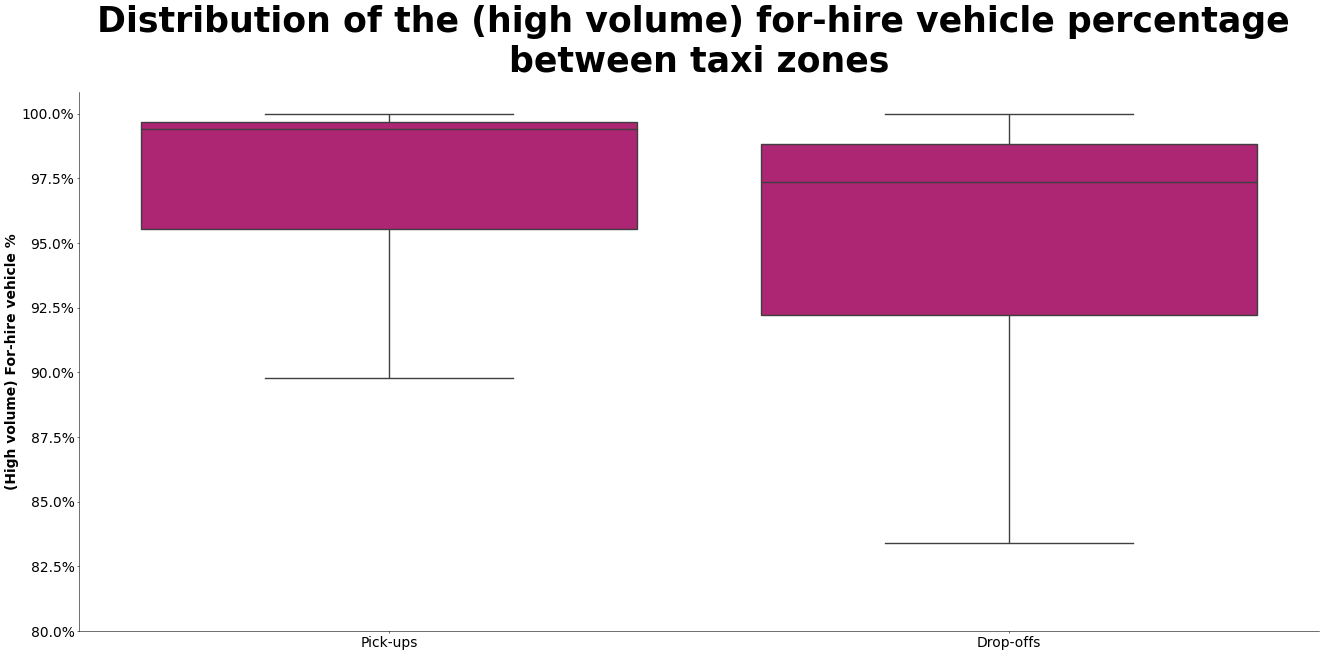

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Data Aggregation: Taxi Zone FHVHV Percentage
# ---------------------------------------------------------
# Group by location IDs to calculate the mean FHVHV percentage for 
# pick-ups and drop-offs independently, then label and combine the sets.
hourly_PUs = PUs_df.groupby(["PULocationID"])["fhvhv_percentage"].mean().reset_index()
hourly_DOs = DOs_df.groupby(["DOLocationID"])["fhvhv_percentage"].mean().reset_index()

hourly_PUs["type"] = "Pick-ups"
hourly_DOs["type"] = "Drop-offs"

hourly_combined = pd.concat([hourly_PUs, hourly_DOs])

# ---------------------------------------------------------
# 2. Visualization: Zone Comparison Boxplot for FHVHV
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a boxplot comparing pick-up and drop-off FHVHV percentage distributions.
sns.boxplot(
    data=hourly_combined,
    x="type",
    y="fhvhv_percentage",
    color="#C21078",
    linewidth=2,
    showfliers=False
)

# Set lower limit to emphasize the distribution variance.
plt.ylim(bottom=0.8)

# Set titles, axes labels, and formatting.
plt.title("Distribution of the (high volume) for-hire vehicle percentage \nbetween taxi zones",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("", fontweight="bold")
plt.ylabel("(High volume) For-hire vehicle %", fontweight="bold")

# Format the y-axis to display values as percentages.
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

# plt.savefig("Plots/Distributions/FHVHV/PUsandDOSFHVHVBoxplot.png", dpi=300)
plt.show()

### Time between vehicle request and pickup for for-hire vehicles

Hourly distribution of the time between vehicle request and pickup (request2PU) across weekdays for for-hire vehicles

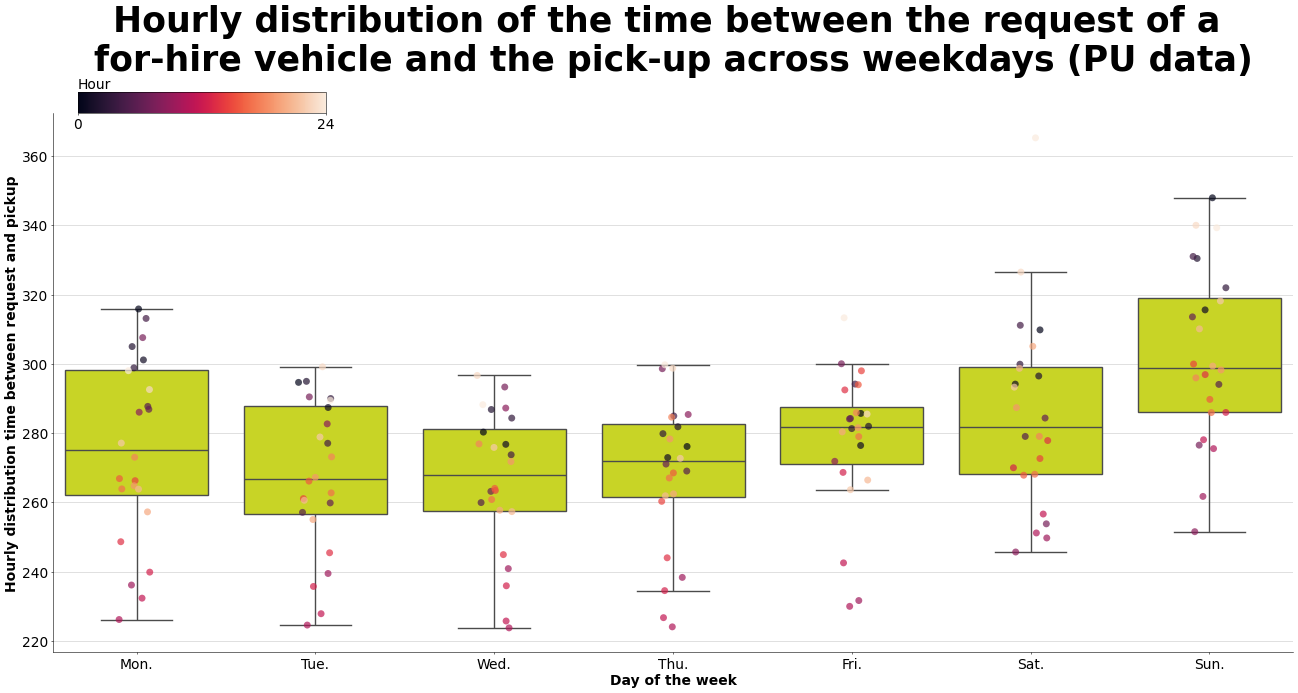

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# ---------------------------------------------------------
# 1. Data Aggregation: Hourly Distribution of Request-to-Pickup Time
# ---------------------------------------------------------
# Group the dataset by day of the week and hour to calculate the mean wait time.
hourly_distPUs = PUs_df.groupby(["DayOfWeek", "hour"])["request2PU"].mean().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Boxplot + Stripplot Overlay
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Generate a boxplot mapping the day of the week to the wait times.
sns.boxplot(
    data=hourly_distPUs,
    x="DayOfWeek",
    y="request2PU",
    color="#E1F109",       
    linewidth=2,         
    showfliers=False  
)

# Overlay a stripplot to show individual hourly data points, colored by hour.
sns.stripplot(
    data=hourly_distPUs,
    x="DayOfWeek",
    y="request2PU",
    alpha=0.7,
    hue="hour",
    palette="rocket",
    size=10,
    legend=False 
)

# Set title, axes labels, margins, and formatting.
plt.title("Hourly distribution of the time between the request of a \nfor-hire vehicle and the pick-up across weekdays (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.xlabel("Day of the week", fontweight="bold")
plt.ylabel("Hourly distribution time between request and pickup", fontweight="bold")
plt.margins(x=0.01)

# Configure a horizontal grid and ensure it renders behind the plot elements.
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.gca().set_axisbelow(True)

# Format x-axis ticks to display abbreviated day names.
plt.xticks(range(0, 7), labels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."])

# ---------------------------------------------------------
# 3. Custom Colorbar: Hour Mapping for Stripplot
# ---------------------------------------------------------
# Set up custom inset colorbar matching the 'rocket' palette used in the stripplot.
# (AI generated)
norm = mcolors.Normalize(vmin=0, vmax=24)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="rocket")
cax = plt.gca().inset_axes([0.02, 1, 0.2, 0.04])

cbar = plt.colorbar(
    scalar_mappable, cax=cax, orientation="horizontal", ticks=[0, 24]
)

cbar.outline.set_visible(True)
cbar.ax.xaxis.set_tick_params(labelsize=20, pad=2)
cax.set_title("Hour", fontsize=20, loc="left", pad=5) 

# plt.savefig("Plots/Distributions/TripRequests/PUsDailyHourlyRequest2PUBoxplot.png", dpi=300)
plt.show()